In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import atan, degrees, gcd
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Dataset
from collections import Counter, defaultdict
from itertools import permutations
import random, math, copy
from tqdm.auto import tqdm
from scipy.stats import pearsonr
from scipy.io import loadmat
from scipy.signal import butter, filtfilt, detrend, resample_poly, iirnotch
import mne 
import re
from pathlib import Path



C:\Users\david\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def phaze_randomize(ts):
    # Phase randomise the data set for surrogate testing.
    #psudo code follow this pattern: 
    # Compute the FFT of the time series to obtain frequency components.
    # Extract the amplitude and phase of each frequency component.
    # Generate random phases uniformly distributed between 0 and 2π.
    # Combine the original amplitudes with the random phases.
    # Perform the inverse FFT to obtain the phase-randomized time series.
    # Return the phase-randomized time series.
    ts = np.asarray(ts, dtype=float)
    N = len(ts)
    fft_ts = np.fft.rfft(ts)
    amplitudes = np.abs(fft_ts)
    random_Phz = np.exp(1j * np.random.uniform(0, 2 * np.pi, len(fft_ts)))
    random_Phz[0] = 1.0
    if N % 2 == 0:
        random_Phz[-1] = 1.0
    new_Hz = amplitudes * random_Phz
    return np.fft.irfft(new_Hz, n=N)

In [ ]:
def normalise_rows(counts, axis=-1, eps=0.0):
    # Normalize rows of a count matrix to probabilities with optional smoothing for zero counts.
    # psudo code follow this pattern:
    # Add a small constant (eps) to each count to avoid zero probabilities.
    # Sum the counts along the specified axis (rows or columns).
    # Divide each count by the corresponding row sum to obtain probabilities.
    # Return the normalized probability matrix.
    probs = counts.astype(float) + eps
    denominator = probs.sum(axis=axis, keepdims=True)
    denominator[denominator == 0] = 1.0
    return probs / denominator

def entropy_rows(P):
    # Row-wise Shannon entropy for a 2D probability matrix.
    # Interprets each row as a discrete conditional distribution, e.g.:
    # row i = P(Y_{t+1} | Y_t = i)
    # Returns entropy per row in bits.
    # log2(0) is undefined; mask zeros because p*log(p) -> 0 as p -> 0
    # H = -sum_j p_j log2(p_j) computed along columns for each row
    with np.errstate(divide='ignore', invalid='ignore'):
        log_P = np.where(P > 0, np.log2(P), 0.0)
    return -np.sum(P * log_P, axis=-1)

def thrD_tens_entropy(P):
    # Entropy over the 'next-state' axis of a 3D conditional probability tensor.
    # Expected shape (ny, ny, nx) where:
    # P[i, j, k] = P(Y_{t+1}=j | Y_t=i, X_{t-lag}=k)
    with np.errstate(divide='ignore', invalid='ignore'):
        log_P = np.where(P > 0, np.log2(P), 0.0)
    return -np.sum(P * log_P, axis=1)

def unconditional_transition_matrix(catY, smoothing=0.0, y_index=None):
    # Build an unconditional 1-step transition model for Y:
    y_syms = pd.Index(sorted(set(catY))) if y_index is None else pd.Index(y_index)
    n = len(y_syms)
    idx = {s: i for i, s in enumerate(y_syms)}
    counts = np.zeros((n, n), dtype=np.int64)
    for t in range(len(catY) - 1):
        i = idx[catY[t]]
        j = idx[catY[t + 1]]
        counts[i, j] += 1
    P = normalise_rows(counts, axis=1, eps=smoothing)
    return pd.DataFrame(P, index=y_syms, columns=y_syms), pd.DataFrame(counts, index=y_syms, columns=y_syms), y_syms

def conditional_transfer_matrix(catX, catY, lag=1, smoothing=0.0, y_index=None, x_index=None):
    # Build conditional transition tensor for TE:
    y_syms = pd.Index(sorted(set(catY))) if y_index is None else pd.Index(y_index) # Y symbols
    x_syms = pd.Index(sorted(set(catX))) if x_index is None else pd.Index(x_index) # X symbols
    ny, nx = len(y_syms), len(x_syms)
    idx_y = {s: i for i, s in enumerate(y_syms)}
    idx_x = {s: i for i, s in enumerate(x_syms)}
    counts = np.zeros((ny, ny, nx), dtype=np.int64)
    T = min(len(catY) - 1, len(catX))
    for t in range(lag, T):
        i = idx_y[catY[t]]
        j = idx_y[catY[t + 1]]
        k = idx_x[catX[t - lag]]
        counts[i, j, k] += 1
    P = counts.astype(float) + smoothing
    denominator = P.sum(axis=1, keepdims=True)
    denominator[denominator == 0] = 1.0
    P /= denominator
    pair_counts = counts.sum(axis=1)
    return P, counts, pair_counts, y_syms, x_syms

def TE_of_transition_matrices(catX, catY, lag=1, smoothing=0.0):
    # Entropies are computed for each conditioning context and then averaged using frequencies from the transition counts.
    #    TE: non-negative TE estimate in bits
    #    H_uncond: H(Y_{t+1} | Y_t)
    #    H_cond:   H(Y_{t+1} | Y_t, X_{t-lag})
    Pyy_df, Cyy_df, y_index = unconditional_transition_matrix(catY, smoothing=smoothing)
    Pyy = Pyy_df.to_numpy()
    Cyy = Cyy_df.to_numpy()
    Hy1_given_y = entropy_rows(Pyy)
    row_sums = Cyy.sum(axis=1)
    total = row_sums.sum()
    H_uncond = 0.0 if total == 0 else float(np.sum((row_sums / total) * Hy1_given_y))
    P_cond, C_cond, pair_counts_ik, _, _ = conditional_transfer_matrix(catX, catY, lag=lag, smoothing=smoothing, y_index=y_index)
    H_y1_given_yx = thrD_tens_entropy(P_cond)
    w_ik_total = pair_counts_ik.sum()
    H_cond = 0.0 if w_ik_total == 0 else float(np.sum((pair_counts_ik / w_ik_total) * H_y1_given_yx))
    TE = max(0.0, H_uncond - H_cond)
    return TE, H_uncond, H_cond

def te_max_over_lags(catX, catY, lags=(10,20,30), smoothing=0.0):
    # Compute TE_{X→Y} for multiple candidate lags and return:
    # A lag-wise table of TE and component entropies and the maximum TE across lags (common heuristic in neuro settings)
    out = []
    for L in lags:
        TE, Hu, Hc = TE_of_transition_matrices(catX, catY, lag=L, smoothing=smoothing)
        out.append({"lag": L, "TE": TE, "H_uncond": Hu, "H_cond": Hc})
    df = pd.DataFrame(out).sort_values("lag")
    return df, float(df["TE"].max())

def entropy_helper(count, N):
    # Compute Shannon entropy from a dictionary of counts
    # Entropy in bits.
    H = 0.0
    for c in count.values():
        p = c / N
        if p > 0:
            H -= p * np.log2(p)
    return H

In [ ]:
def MMC(k, N):
    # Miller-Madow correction for entropy estimation.
    if N <= 0 or k <= 1:
        return 0.0
    return (k - 1) / (2.0 * N * np.log(2.0))

def entropy_mm(count, N):
    # Entropy with Miller-Madow correction.
    return entropy_helper(count, N) + MMC(len(count), N)

def zscore_channels(data):
    # Z-score each channel independently.
    # Standardising each channel prevents amplitude scale differences across parcels from dominating feature extraction and learning.
    # If a channel has zero variance, std is set to 1 to avoid division by zero.
    
    mean = data.mean(axis=1, keepdims=True)
    std = data.std(axis=1, keepdims=True)
    std[std == 0] = 1.0
    return (data - mean) / std

def zscore_trial(x):
    # Z-score a single trial/epoch.
    # Accepts either:
    # 1D: shape (n_times,) > z-score across time
    # 2D: shape (n_channels, n_times) > per-channel z-score
    # Provides a consistent normalisation interface regardless of whether the code is operating on a single-channel or multi-channel representation.
    x = np.asarray(x)
    if x.ndim == 1:
        mu = x.mean()
        sd = x.std()
        if sd == 0:
            sd = 1.0
        return (x - mu) / sd
    elif x.ndim == 2:
        return zscore_channels(x)
    else:
        raise ValueError(f"Expected 1D or 2D array, got shape {x.shape}")


def z_from_null(te_obs, null):
    # Compute a z-score for an observed statistic relative to a null distribution.
    # Rationale
    # Provides a standardised effect size relative to surrogate chance levels.
    # Useful for significance scoring or downstream thresholding.
    null = np.asarray(null, dtype=float)
    mu = float(null.mean()) if len(null) else 0.0
    sd = float(null.std(ddof=1)) if len(null) > 1 else 0.0
    z  = (te_obs - mu) / sd if sd > 0 else (np.inf if te_obs > mu else -np.inf)
    return z, mu, sd

In [ ]:
def sym_trsf_ent(catX, catY, lags=1, use_mm=True):
    # Symbolic Transfer Entropy estimator using joint symbol counts.
    YYX, YY, XY, Y = [], [], [], []
    for t in range(lags, len(catY) - 1):
        YYX.append((catY[t + 1], catX[t - lags], catY[t]))
        YY.append((catY[t + 1], catY[t]))
        XY.append((catX[t - lags], catY[t]))
        Y.append(catY[t])
    if len(YYX) == 0:
        return 0.0
    if use_mm:
        HYYX = entropy_mm(Counter(YYX), len(YYX))
        HYY  = entropy_mm(Counter(YY),  len(YY))
        HXY  = entropy_mm(Counter(XY),  len(XY))
        HY   = entropy_mm(Counter(Y),   len(Y))
    else:
        HYYX = entropy_helper(Counter(YYX), len(YYX))
        HYY  = entropy_helper(Counter(YY),  len(YY))
        HXY  = entropy_helper(Counter(XY),  len(XY))
        HY   = entropy_helper(Counter(Y),   len(Y))
    TE = HYY + HXY - HYYX - HY
    return max(0.0, TE)

In [ ]:
def triangle_feats_arrays(ts):
    #Compute triangle-based geometric features from a 1D time series using, overlapping triplets (y1, y2, y3) with fixed time step dx=1.
    #For each t, the triangle is defined by points:
    #    (t,   y1), (t+1, y2), (t+2, y3)
    ts = np.asarray(ts, dtype=np.float32)
    y1 = ts[:-2]
    y2 = ts[1:-1]
    y3 = ts[2:]
    # slopes with dx=1
    slope_left  = (y2 - y1)
    slope_right = (y3 - y2)
    # angle between lines using arctan formula
    denom = (1.0 + slope_right * slope_left)
    denom = np.where(denom == 0, 1e-12, denom)
    angle = np.degrees(np.arctan(np.abs((slope_right - slope_left) / denom)))
    # triangle area with x spacing fixed: use Heron's formula with vector lengths
    a = np.sqrt(1.0 + (y2 - y1)**2)
    b = np.sqrt(1.0 + (y3 - y2)**2)
    c = np.sqrt(4.0 + (y3 - y1)**2)
    s = 0.5 * (a + b + c)
    area = np.sqrt(np.maximum(s * (s-a) * (s-b) * (s-c), 0.0))
    amp = y2
    return area, angle, amp

def make_quantile_bins(values, n_bins, add_inf=True):
    # Construct quantile-based bin edges for discretising continuous values.
    # Quantile binning is used to avoid sparse bins (roughly equal mass per bin) which helps stabilise symbolic counts and entropy estimates.
    values = np.asarray(values)
    qs = np.linspace(0.0, 1.0, n_bins + 1)
    edges = np.quantile(values, qs)
    edges = np.unique(edges)
    if len(edges) < 2:
        raise ValueError("Not enough unique values to form bins.")
    if add_inf:
        edges = np.concatenate(([-np.inf], edges, [np.inf]))
    return edges

def build_bins_from_pairs_subsample(pairs, n_bins=3, max_pairs=5000, seed=0):
    #Build GLOBAL quantile bin edges (area, angle, amp) using a random subsample of (X,Y) pairs.
    #Why subsample?
    # - Avoids loading / concatenating all data (memory + speed).
    # - Quantile estimation is robust with modest sample sizes.
    rng = np.random.default_rng(seed)
    n = len(pairs)
    idx = rng.choice(n, size=min(max_pairs, n), replace=False)
    areas_all  = []
    angles_all = []
    amps_all   = []
    for i in idx:
        x, y = pairs[i]
        ax, angx, ampx = triangle_feats_arrays(x)
        ay, angy, ampy = triangle_feats_arrays(y)
        areas_all.append(ax);  areas_all.append(ay)
        angles_all.append(angx); angles_all.append(angy)
        amps_all.append(ampx); amps_all.append(ampy)
    areas  = np.concatenate(areas_all).astype(np.float32, copy=False)
    angles = np.concatenate(angles_all).astype(np.float32, copy=False)
    amps   = np.concatenate(amps_all).astype(np.float32, copy=False)
    area_bins  = make_quantile_bins(areas,  n_bins, add_inf=True)
    angle_bins = make_quantile_bins(angles, n_bins, add_inf=True)
    amp_bins   = make_quantile_bins(amps,   n_bins, add_inf=True)
    return (area_bins, angle_bins, amp_bins)

def Bin_Bulder(features_x, features_y, n_bins=10):
    # Build global quantile bins from pre-computed feature dicts.
    # NTS: This function expects *lists of dictionaries* with keys:
    #    "area", "angle_degree", "amplitude"
    # It pools X and Y features to ensure bins are consistent across both series.
    both = features_x + features_y
    areas  = np.array([f["area"] for f in both])
    angles = np.array([f["angle_degree"] for f in both])
    amps   = np.array([f["amplitude"] for f in both])
    area_bins  = make_quantile_bins(areas,  n_bins, add_inf=True)
    angle_bins = make_quantile_bins(angles, n_bins, add_inf=True)
    amp_bins   = make_quantile_bins(amps,   n_bins, add_inf=True)
    return area_bins, angle_bins, amp_bins

def cats_from_arrays(amp, area, ang, bins):
    #Discretise triangle feature arrays into a single integer symbol per timestep.
    #Each timestep gets 3 discrete indices:
    #  - ar : area bin
    #  - an : angle bin
    #  - am : amplitude bin
    #These are combined into a single code via a mixed-radix mapping:
    #This yields a symbolic sequence suitable for transition counting + TE.
    area_bins, angle_bins, amp_bins = bins
    ar = np.digitize(area, area_bins) - 1
    an = np.digitize(ang,  angle_bins) - 1
    am = np.digitize(amp,  amp_bins) - 1
    nA = len(area_bins)  - 1
    nN = len(angle_bins) - 1
    nM = len(amp_bins)   - 1
    ar = np.clip(ar, 0, nA - 1)
    an = np.clip(an, 0, nN - 1)
    am = np.clip(am, 0, nM - 1)
    code = (ar * nM + am) * nN + an
    return code.astype(np.int32), (nA, nM, nN)

def lag_compute_TE(catX, catY, lags=(10,20, 30), use_mm=True):
    # Compute TE over multiple candidate lags and return the maximum.
    # Rationale:
    # - TE depends on lag choice (physiology / conduction delays / dynamics).
    # - Taking max-over-lags approximates "best predictive lag" without assuming a single fixed delay.
    best = 0.0
    for L in lags:
        val = sym_trsf_ent(catX, catY, lags=L, use_mm=use_mm)
        if val > best:
            best = val
    return best
LAGS = tuple(range(3, 5))  # i should dreplace this with a physiological range later

def metric_series_loop_with_bins(x, y, bins, lags=None, use_mm=True):
    #End-to-end EPSTE feature extraction for a single (x,y) pair:
    # 1) Compute triangle features for x and y
    # 2) Quantise (area, angle, amp) into symbolic codes using global bins
    # 3) Compute TE_{x→y} via symbolic estimator (max over lags)
    # 4) Compute marginal symbol counts for x and y (useful as NN inputs)
    if lags is None:
        lags = LAGS
    ax, gx, mx = triangle_feats_arrays(x)
    ay, gy, my = triangle_feats_arrays(y)
    catX, radixX = cats_from_arrays(mx, ax, gx, bins)  
    catY, radixY = cats_from_arrays(my, ay, gy, bins)
    te_xy = lag_compute_TE(catX.tolist(), catY.tolist(), lags=lags, use_mm=use_mm)
    # counts length from bins (not n_bins**3)
    area_bins, angle_bins, amp_bins = bins
    K = (len(area_bins)-1) * (len(angle_bins)-1) * (len(amp_bins)-1)
    counts_x = np.bincount(catX, minlength=K)
    counts_y = np.bincount(catY, minlength=K)
    return {"te_xy": te_xy, "counts_x": counts_x, "counts_y": counts_y}

# Surrogate test
def categories_from_features(feats):
    # Extract category labels from features list for TE my computation
    return [f["category"] for f in feats]


In [7]:
def categories_from_features(feats):
    # Extract category labels from features list for TE my computation
    return [f["category"] for f in feats]

def te_from_features(feats_x, feats_y, lags, use_mm=True):
    # Compute TE from features by extracting categories
    return lag_compute_TE(categories_from_features(feats_x),
                          categories_from_features(feats_y),
                          lags=lags, use_mm=use_mm)


In [ ]:

def surrogate_one_dir(x_raw, y_raw, bins, lags=(10,20,30), n_surr=25, use_mm=True, seed=42):
    #One-direction surrogate significance test for TE_{X→Y} using phase-randomised surrogates.
    # Pipeline:
    # 1) Convert raw X and Y into triangle feature streams (area, angle, amplitude).
    # 2) Quantise features into a discrete symbol sequence using global bin edges.
    # 3) Compute observed TE_{X→Y} as max-over-lags TE on symbol sequences.
    # 4) Generate null distribution by phase-randomising X (preserves power spectrum, disrupts temporal structure), recompute TE_{X_surr→Y}.
    # 5) Compute a one-sided Monte Carlo p-value: P(null >= observed).
    # RNG is created for reproducibility, but note: phaze_randomize should accept/use rng
    rng = np.random.default_rng(seed)
    ax, gx, mx = triangle_feats_arrays(x_raw)
    ay, gy, my = triangle_feats_arrays(y_raw)
    sx, _ = cats_from_arrays(mx, ax, gx, bins)
    sy, _ = cats_from_arrays(my, ay, gy, bins)
    sx = sx.tolist()
    sy = sy.tolist()
    te_obs = lag_compute_TE(sx, sy, lags=lags, use_mm=use_mm)
    null = np.zeros(n_surr, dtype=np.float32)
    for k in range(n_surr):
        x_surr = phaze_randomize(x_raw)  # ideally uses rng inside; see note below
        ax_s, gx_s, mx_s = triangle_feats_arrays(x_surr)
        sx_s, _ = cats_from_arrays(mx_s, ax_s, gx_s, bins)
        sx_s = sx_s.tolist()
        null[k] = lag_compute_TE(sx_s, sy, lags=lags, use_mm=use_mm)
    p = (1.0 + np.sum(null >= te_obs)) / (len(null) + 1.0)
    return {"te_obs": float(te_obs), "p": float(p), "null": null}

    

In [ ]:
def build_fixed_vocab(symbols, add_unk=True):
    # Build a fixed integer vocabulary from a collection of symbolic states.
    syms = sorted(set(symbols))
    if add_unk:
        vocab = {s: i + 1 for i, s in enumerate(syms)}
        vocab["<UNK>"] = 0
    else:
        vocab = {s: i for i, s in enumerate(syms)}
    return vocab

def cat_to_idx(seq, vocab):
    #Convert a categorical symbol sequence into integer indices using a fixed vocabulary.
    #Any symbol not present in the vocabulary is mapped to <UNK> (index 0 if defined).
    unk = vocab.get("<UNK>", 0)
    return np.array([vocab.get(s, unk) for s in seq], dtype=np.int64)


def all_categories_for_pair(x, y, bins):
    # Extract full categorical symbol sequences for a signal pair (X, Y).
    # Used when global symbol statistics (e.g., vocab construction or analysis) are required rather than windowed samples.
    ax, gx, mx = triangle_feats_arrays(x)
    ay, gy, my = triangle_feats_arrays(y)
    catX, radixX = cats_from_arrays(mx, ax, gx, bins)  
    catY, radixY = cats_from_arrays(my, ay, gy, bins)
    return catX, catY

def symbolize_pair(x, y, bins):
    #Convert a raw signal pair into symbolic sequences using triangle-based encoding.
    #This is the main entry point for symbolic representation in EPSTE.
    ax, gx, mx = triangle_feats_arrays(x)
    ay, gy, my = triangle_feats_arrays(y)
    symX, _ = cats_from_arrays(mx, ax, gx, bins)
    symY, _ = cats_from_arrays(my, ay, gy, bins)
    return symX.tolist(), symY.tolist()

def label_te(catX, catY):
    # Label TE for a pair of categorical sequences
    _, te_max = te_max_over_lags(catX, catY, lags=(10, 20, 30), smoothing=0.0)
    return float(te_max)

def windows_from_symbol_ids(x_ids, y_ids, LAG, W, stride=1):
    # Construct aligned symbolic windows for multiple-instance learning.
    samples = []
    T = min(len(y_ids), len(x_ids) +LAG)
    for t0 in range(LAG, T -W, stride):
        x_win = x_ids[t0-LAG: t0 -LAG +W]
        y_win = y_ids[t0:t0 + W]
        if len(x_win) == W and len(y_win) == W:
            samples.append(np.stack([x_win, y_win], axis=1))
    return samples

def compute_pair_labels(pairs, bins, lags=None, use_mm=True, direction="xy"):
    # Compute pair-level symbolic TE labels for a list of time-series pairs.
    if lags is None:
        lags = LAGS
    pair_y = np.zeros(len(pairs), dtype=np.float32)
    for i, (x, y) in enumerate(pairs):
        res = metric_series_loop_with_bins(x, y,bins=bins,lags=lags,use_mm=use_mm)
        pair_y[i] = res["te_xy"]
    return pair_y

def build_windows_with_pair_labels(pairs, pair_y, bins, vocab_x, vocab_y, W, LAG, stride): # EDIT OUT
    # Build window-level symbolic samples with pair-level TE labels.
    # Each window inherits the TE label of its parent pair.
    X_list, y_list, pid_list = [], [], []
    assert len(pair_y) == len(pairs), "pair_y must align 1:1 with pairs"
    for pid, (x, y) in enumerate(pairs):
        catX, catY = symbolize_pair(x, y, bins)
        T = len(catY)
        for t0 in range(LAG, T - W + 1, stride):
            x_seg = catX[t0 - LAG : t0 - LAG + W]
            y_seg = catY[t0 : t0 + W]
            x_ids = cat_to_idx(x_seg, vocab_x)
            y_ids = cat_to_idx(y_seg, vocab_y)
            X_list.append(np.stack([x_ids, y_ids], axis=1))  # [W,2]
            y_list.append([pair_y[pid]])                     # [1]
            pid_list.append(pid)                             # pair id
    if not X_list:
        return None, None, None
    X = torch.tensor(np.stack(X_list), dtype=torch.long)        # [N,W,2]
    y = torch.tensor(np.array(y_list), dtype=torch.float32)     # [N,1]
    p = torch.tensor(np.array(pid_list), dtype=torch.long)      # [N]
    return X, y, p

def build_pairbags_with_pair_labels(pairs, pair_y, bins, vocab_x, vocab_y, W, LAG, stride=1, meta=None):
    # Construct bag-of-windows representation for each pair.
    # Each pair yields a variable number of windows (MIL setting).
    assert len(pair_y) == len(pairs), "pair_y must align 1:1 with pairs"
    pairX_list = []
    y_list = []
    meta_list = []
    for pid, (x, ysig) in enumerate(pairs):
        catX, catY = symbolize_pair(x, ysig, bins)   # lists of symbols
        T = len(catY)
        X_windows = []
        for t0 in range(LAG, T - W + 1, stride):
            x_seg = catX[t0 - LAG : t0 - LAG + W]
            y_seg = catY[t0 : t0 + W]
            x_ids = cat_to_idx(x_seg, vocab_x)
            y_ids = cat_to_idx(y_seg, vocab_y)
            X_windows.append(np.stack([x_ids, y_ids], axis=1))  # (W,2)
        if len(X_windows) == 0:
            continue
        pairX = torch.tensor(np.stack(X_windows), dtype=torch.long)  # (n_win, W, 2)
        pairX_list.append(pairX)
        y_list.append([float(pair_y[pid])])
        if meta is not None:
            meta_list.append(meta[pid])
    y_out = torch.tensor(np.array(y_list), dtype=torch.float32)  # (n_pairs,1)
    if meta is not None:
        return pairX_list, y_out, meta_list
    return pairX_list, y_out, None


class PairBagDataset(Dataset):
     # Dataset wrapper for pair-level bags of symbolic windows.
    # Each item corresponds to a single channel pair.
    # X : torch.LongTensor (n_win, W, 2)
    # y : torch.FloatTensor (1,)
    # meta : dict (optional)
    def __init__(self, pairX_list, y, meta_list=None):
        self.pairX_list = pairX_list
        self.y = y
        self.meta_list = meta_list
    def __len__(self):
        return len(self.pairX_list)
    def __getitem__(self, idx):
        if self.meta_list is None:
            return self.pairX_list[idx], self.y[idx]
        return self.pairX_list[idx], self.y[idx], self.meta_list[idx]

def collate_pairbags(batch):
    # Custom collate function for variable-length pair bags.
    # Pads window dimension to max number of windows in batch.
    has_meta = (len(batch[0]) == 3)
    if has_meta:
        X_list, y_list, meta_list = zip(*batch)
    else:
        X_list, y_list = zip(*batch)
        meta_list = None
    B = len(X_list)
    W = X_list[0].shape[1]   # window length
    D = X_list[0].shape[2]   # should be 2 (x_ids,y_ids)
    nwin = [x.shape[0] for x in X_list]
    max_nwin = max(nwin)
    X_pad = torch.zeros(B, max_nwin, W, D, dtype=torch.long)
    mask  = torch.zeros(B, max_nwin, dtype=torch.bool)
    for i, x in enumerate(X_list):
        X_pad[i, :x.shape[0]] = x
        mask[i, :x.shape[0]] = True
    y = torch.stack(y_list).float()  # (B,1)
    if has_meta:
        return X_pad, mask, y, list(meta_list)
    return X_pad, mask, y



In [ ]:
def notch_filter(data, fs, freqs=(50.0, 100.0), Q=30.0):
    # Apply notch filtering to remove line noise and harmonics.
    #  iirnotch designs a narrow band-stop filter at the specified frequency.
    #  filtfilt is used for zero-phase filtering (no phase distortion).
    #  Frequencies above Nyquist (fs/2) are skipped safely.
    
    out = data.copy()
    for f0 in freqs:
        if f0 >= fs / 2:  
            continue
        b, a = iirnotch(w0=f0/(fs/2), Q=Q) 
        out = filtfilt(b, a, out, axis=1)
    return out

def lowpass_filter(data, fs, cutoff=45.0, order=4):
    # Low-pass filter to remove high-frequency components.
    # Low-pass filtered data (zero-phase).
    
    if cutoff >= fs / 2:
        return data
    b, a = butter(order, cutoff/(fs/2), btype="low")
    return filtfilt(b, a, data, axis=1)

def downsample_meg(data, fs, target_fs=250):
    # Downsample using polyphase resampling (anti-aliasing included).
    # Notes:
    # Resample_poly performs up/down sampling with an implicit low-pass anti-aliasing filter, which is well-suited to integer ratio changes.
    # Reduce the ratio via gcd for numerical stability and efficiency.
    
    if fs == target_fs:
        return data, fs
    g = gcd(int(fs), int(target_fs))
    up = target_fs // g
    down = fs // g
    data_ds = resample_poly(data, up, down, axis=1)
    return data_ds, target_fs

def inspect_mat(fp):
    # Utility helper: inspect .mat file contents (keys, shapes, dtypes).
    # This is used during development to confirm how the dataset is stored and to identify which variables correspond to signal arrays.
    mat = loadmat(fp)
    keys = [k for k in mat.keys() if not k.startswith("__")]
    print(fp.name, "keys:", keys)
    for k in keys:
        arr = mat[k]
        if hasattr(arr, "shape"):
            print(" ", k, "shape:", arr.shape, "dtype:", getattr(arr, "dtype", None))

def MEG_pre_process (data, fs, target_fs=250,line_freqs=(50.0, 100.0),lowpass_cutoff=45.0):
    # Minimal MEG preprocessing pipeline used in this dissertation.
    # Steps:
    # 1) Notch filter at 50/100 Hz to remove line noise
    # 2) Low-pass filter to remove higher-frequency noise
    # 3) Downsample to reduce compute while retaining temporal resolution
    # 4) Channel-wise z-score normalisation
    # Notes:
    #  filtfilt ensures zero-phase filtering (no temporal shift).
    #  ICA/EOG regression could be added here (e.g., MNE) if raw sensor data were available; 
    # skipped because input is already source-reconstructedand artefact epochs are pre-removed upstream.

    data = notch_filter(data, fs, freqs=line_freqs)
    data = lowpass_filter(data, fs, cutoff=lowpass_cutoff)
    data, new_fs = downsample_meg(data, fs, target_fs=target_fs)
    data = zscore_channels(data)
    # NTS: ICA could be inserted here using MNE but perhaps i should skip it for simplicity???
    return data, new_fs

In [ ]:


def load_MEG_trials(folder_path,data_key=None,fs_key=None,suffix=".mat",target_fs=250,default_fs=300.0):

    # Load and preprocess MEG trials from MATLAB files.
    # This function iterates over all .mat files in a directory and extracts
    # trial-level MEG data in a consistent (channels × time) format.
    # Operations:
    #  Automatically identifies the primary MEG data array by searching for a 3D numeric array (channels × time × trials) when a data key is not provided
    #  Infers the sampling rate from file metadata where possible, falling back to a default value if unavailable
    #  Enforces a consistent array orientation (channels x time x trials), transposing axes if required
    #  Applies the MEG_pre_process pipeline independently to each trial to standardise filtering, downsampling, and normalisation
    #  Preserves trial-level metadata (subject, drug condition, trial index, source file) to support later aggregation and analysis.
    #  Notes:
    #  Preprocessing is performed on a per-trial basis to avoid leakage ofstatistics across trials or subjects
    #  The loader is intentionally robust to variations in .mat file structure and variable naming conventions.
    
    folder = Path(folder_path)
    file_paths = sorted(p for p in folder.iterdir() if p.is_file() and p.suffix == suffix)
    trials = []
    for fp in file_paths:
        mat = loadmat(fp)
        keys = [k for k in mat.keys() if not k.startswith("__")]
        #choose data key
        dk = data_key
        if dk is None or dk not in mat:
            for k in keys:
                arr = mat[k]
                if hasattr(arr, "ndim") and arr.ndim == 3 and np.issubdtype(arr.dtype, np.number):
                    dk = k
                    break
            if dk is None:
                raise ValueError(f"No 3D numeric array found in {fp.name}")
        data = mat[dk]
        #sampling rate
        fs = default_fs
        if fs_key and fs_key in mat:
            fs = float(np.squeeze(mat[fs_key]))
        else:
            for cand in ["fs", "Fs", "srate", "sfreq", "SR"]:
                if cand in mat:
                    fs = float(np.squeeze(mat[cand]))
                    break
        #enforce (chan, time, trials)
        if data.shape[0] > data.shape[1] and data.shape[1] < 500:
            data = np.transpose(data, (1, 0, 2))
        if data.ndim != 3:
            raise ValueError(f"Expected 3D array, got {data.shape} in {fp.name}")
        drug, subject = parse_drug_subject(fp.name)
        for trial_idx in range(data.shape[2]):
            raw_trial = data[:, :, trial_idx]   # [chan, time]
            trial_pre, new_fs = MEG_pre_process(raw_trial, fs, target_fs)
            trials.append({
                "data": trial_pre,
                "subject": subject,
                "drug": drug,
                "trial_idx": trial_idx,
                "file": fp.name,})
    return trials

def make_pairs_from_trials(trials, channel_pairs):
    # Build (x, y) time-series pairs from EEG trials and channel combinations.
    # trials : list of dicts
    # Each dict contains trial data and metadata.
    # channel_pairs : list of (int, int) 
    # List of channel index pairs (source, target) to extract per trial.
    pairs = []
    meta  = []
    for trial in trials:
        data = trial["data"]
        for cx, cy in channel_pairs:
            x = zscore_trial(data[cx])
            y = zscore_trial(data[cy])
            pairs.append((x, y))
            meta.append({
                "subject": trial["subject"],
                "drug": trial["drug"],
                "trial_idx": trial["trial_idx"],
                "file": trial["file"],
                "channel_x": cx,
                "channel_y": cy,})
    return pairs, meta

def parse_drug_subject(fname: str):
    # Assert drug condition, subject and file name
    base = fname.replace(".mat", "")
    drug = None
    subj = None
    
    m = re.match(r"([A-Za-z0-9]+)_", base)
    if m:
        drug = m.group(1)
    # subject: capture "subject_01" or "sub_01" etc
    m2 = re.search(r"(subject|sub)[-_]?(\d+)", base, flags=re.IGNORECASE)
    if m2:
        subj = int(m2.group(2))
    return drug, subj

In [ ]:
class TEPredictor(nn.Module): # EDIT OUT
    # Simple GRU-based regressor for predicting TE from a single symbolic window
    # Operates on paired source/target token sequences without aggregation
    def __init__(self, vocab_x, vocab_y, emb, hidden = 128, layers=2, dropout=0.2):
        super().__init__()
        # Embedding layers for source (x) and target (y) symbolic vocabularies
        self.ex = nn.Embedding(vocab_x, emb)
        self.ey = nn.Embedding(vocab_y, emb)
        # GRU encoder over concatenated (x,y) embeddings
        self.gru = nn.GRU(input_size=emb*2,
                          hidden_size=hidden,
                          num_layers=layers,
                          batch_first=True,
                          dropout=(dropout if layers > 1 else 0.0))
        self.dropout = nn.Dropout(dropout) # Dropout applied to final hidden state
        self.fc = nn.Linear(hidden, 1) # Linear projection to scalar TE estimate

    def forward(self, tokens):  # [B, W, 2]
        # tokens shape: (B, W, 2) where last dim indexes (x_ids, y_ids)
        # Separate source and target symbol indices
        x_ids = tokens[:, :, 0]
        y_ids = tokens[:, :, 1]
        ex = self.ex(x_ids) # Embed discrete symbols
        ey = self.ey(y_ids)
        z = torch.cat([ex, ey], dim=-1)# Concatenate embeddings along feature dimension
        out, _ = self.gru(z) # Encode temporal structure with GRU
        last = out[:, -1, :]  # Use final timestep representation
        last = self.dropout(last) # Predict scalar TE value
        return self.fc(last)
    
class WindowEncoderTokens(nn.Module):
    # Encodes a single symbolic window into a fixed-length embedding
    # Used as the shared window-level encoder in the MIL architecture
    def __init__(self, vocab_x, vocab_y, emb, hidden=128, layers=1, dropout=0.1):
        super().__init__()
        self.ex = nn.Embedding(vocab_x, emb) # Separate embeddings for source and target symbol streams
        self.ey = nn.Embedding(vocab_y, emb)
        self.gru = nn.GRU(input_size=emb * 2, # GRU encoder over concatenated embeddings
                          hidden_size=hidden,
                          num_layers=layers,
                          batch_first=True,
                          dropout=(dropout if layers > 1 else 0.0)) 
        self.dropout = nn.Dropout(dropout) # Dropout for regularisation

    def forward(self, tokens):
        # tokens: (N, W, 2)
        x_ids = tokens[:, :, 0]
        y_ids = tokens[:, :, 1]
        ex = self.ex(x_ids)
        ey = self.ey(y_ids)
        z = torch.cat([ex, ey], dim=-1)   # (N, W, 2*emb) Concatenate embeddings
        out, _ = self.gru(z)
        last = out[:, -1, :]              # (N, H)
        last = self.dropout(last)
        return last # Return final hidden state as window embedding

class MaskedAttentionPooling(nn.Module):
    # Attention-based pooling over variable-length window bags
    # Mask ensures padded windows do not contribute to attention weights
    def __init__(self, hidden_dim=128, attn_dim=64):
        super().__init__() # Small MLP to score each window embedding
        self.score = nn.Sequential(nn.Linear(hidden_dim, attn_dim),
                                   nn.Tanh(),
                                   nn.Linear(attn_dim, 1))
    def forward(self, z, mask):
        # z: (B, M, H), mask: (B, M)
        logits = self.score(z).squeeze(-1)  # (B,M) Compute unnormalised attention logits
        neg_inf = torch.finfo(logits.dtype).min
        logits = logits.masked_fill(~mask, neg_inf) # Mask invalid (padded) windows
        attn = torch.softmax(logits, dim=1) # (B,M) Normalise across windows
        pooled = torch.bmm(attn.unsqueeze(1), z).squeeze(1)  # (B,H) Weighted sum of window embeddings
        pooled = torch.nan_to_num(pooled, nan=0.0, posinf=0.0, neginf=0.0) # Numerical safety
        attn = torch.nan_to_num(attn, nan=0.0, posinf=0.0, neginf=0.0)
        return pooled, attn

class PairTEPredictorAttn(nn.Module):
    # Multiple-instance learning model for pair-level TE prediction
    # Encodes windows independently, then aggregates via attention
    def __init__(self, vocab_x, vocab_y, emb=64, hidden=128, layers=1, dropout=0.1, attn_dim=64):
        super().__init__() # Shared window encoder
        self.enc = WindowEncoderTokens(vocab_x, vocab_y, emb, hidden=hidden, layers=layers, dropout=dropout)
        self.pool = MaskedAttentionPooling(hidden_dim=hidden, attn_dim=attn_dim) # Attention pooling over windows
        self.head = nn.Sequential(nn.Linear(hidden, hidden),
                                  nn.ReLU(),
                                  nn.Linear(hidden, 1))

    def forward(self, X_pad, mask, return_attn=False, return_window_preds=False):
        B, M, W, D = X_pad.shape
        X_flat = X_pad.reshape(B * M, W, D)         # (B*M,W,2)
        z_flat = self.enc(X_flat)                   # (B*M,H)
        z = z_flat.reshape(B, M, -1)                # (B,M,H)
        # window-level predictions (diagnostic)
        yhat_win = self.head(z).squeeze(-1)         # (B,M)
        pooled, attn = self.pool(z, mask)           # pooled: (B,H), attn: (B,M)
        yhat = self.head(pooled)                    # (B,1)
        if return_attn and return_window_preds: # diagnostic outputs
            return yhat, attn, yhat_win
        if return_attn:
            return yhat, attn
        if return_window_preds:
            return yhat, yhat_win
        return yhat

def train_pairbags(model, train_loader, val_loader, num_epochs=50, lr=1e-4, patience=25):
    # Training loop for MIL pair-level TE prediction model
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    crit = torch.nn.SmoothL1Loss(beta=1.0) # Smooth L1 loss for robustness to outliers
    opt  = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=3)  # Learning-rate scheduler based on validation loss
    best_val = float("inf")
    patience_ctr = 0
    best_state = None
    train_loss, val_loss = [], []
    for ep in range(num_epochs): # Training pass
        model.train()
        tr = 0.0
        ntr = 0
        for batch in train_loader: # Expect meta information for aggregation
            if len(batch) == 4:
                X_pad, mask, y, _meta = batch
            else:
                X_pad, mask, y = batch
            X_pad = X_pad.to(device)
            mask  = mask.to(device)
            y     = y.to(device)
            opt.zero_grad()
            yhat = model(X_pad, mask)
            loss = crit(yhat, y)
            loss.backward()
            opt.step()
            tr += loss.item() * y.shape[0]
            ntr += y.shape[0]
        tr /= max(1, ntr)
        model.eval()
        va = 0.0
        nva = 0
        with torch.no_grad(): # Forward pass with diagnostics
            for batch in val_loader:
                if len(batch) == 4:
                    X_pad, mask, y, _meta = batch
                else:
                    X_pad, mask, y = batch
                X_pad = X_pad.to(device)
                mask  = mask.to(device)
                y     = y.to(device)
                yhat = model(X_pad, mask)
                loss = crit(yhat, y)
                va += loss.item() * y.shape[0]
                nva += y.shape[0]
        va /= max(1, nva)
        sched.step(va)
        train_loss.append(tr)
        val_loss.append(va)
        print(f"Epoch {ep+1}/{num_epochs} | Train Loss: {tr:.4f} | Val Loss: {va:.4f}")
        if va < best_val - 1e-6:
            best_val = va
            patience_ctr = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, train_loss, val_loss

def test_pairbags(model, test_loader, agg_level="subject_channel_pair"):
    # Evaluation routine producing window-, bag-, and pair-level outputs
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    bag_rows = []
    win_rows = []
    with torch.no_grad():
        for batch in test_loader:
            # Expect meta to be present for each bag (pair-instance)
            if len(batch) != 4:
                raise ValueError("test_loader must return (X_pad, mask, y, meta_list) for this patch.")
            X_pad, mask, y, meta = batch
            X_pad = X_pad.to(device)
            mask  = mask.to(device)
            y     = y.to(device)
            # Bag prediction + attention + per-window predictions
            yhat_bag, attn, yhat_win = model(X_pad, mask, return_attn=True, return_window_preds=True)
            y_np        = y.squeeze(1).cpu().numpy()             # (B,)
            yhat_np     = yhat_bag.squeeze(1).cpu().numpy()      # (B,)
            yhat_win_np = yhat_win.cpu().numpy()                 # (B,M)
            mask_np     = mask.cpu().numpy()                     # (B,M) bool
            B = y_np.shape[0]
            for i in range(B):
                m = meta[i]  
                bag_rows.append({**m,
                                 "y": float(y_np[i]),
                                 "yhat": float(yhat_np[i]),}) 
                valid = mask_np[i]
                valid_idx = np.where(valid)[0]
                for wpos in valid_idx:
                    win_rows.append({**m,
                                    "win_idx": int(wpos),
                                    "te_window_true": float(y_np[i]),
                                    "te_window_pred": float(yhat_win_np[i, wpos]),})
    bag_df = pd.DataFrame(bag_rows) 
    windows_df = pd.DataFrame(win_rows)

    # metrics helpers
    def mse(a, b):
        a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
        return float(np.mean((a - b) ** 2))

    def pearsonr_safe(a, b):
        a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
        if a.size < 2 or np.std(a) == 0 or np.std(b) == 0:
            return float("nan")
        return float(np.corrcoef(a, b)[0, 1])

    # Window metrics (diagnostic)
    window_metrics = {"mse": mse(windows_df["te_window_pred"].values, windows_df["te_window_true"].values) if len(windows_df) else float("nan"),
                      "r":   pearsonr_safe(windows_df["te_window_pred"].values, windows_df["te_window_true"].values) if len(windows_df) else float("nan"),}

    # Bag metrics (pair-instance)
    bag_metrics = {"mse": mse(bag_df["yhat"].values, bag_df["y"].values),
                   "r":   pearsonr_safe(bag_df["yhat"].values, bag_df["y"].values),}

    # Pair-level aggregation across trials to subject/channel directed edge
    if agg_level == "subject_channel_pair":
        group_cols = ["subject", "drug", "channel_x", "channel_y"]
    elif agg_level == "channel_pair_allsubjects":
        group_cols = ["drug", "channel_x", "channel_y"]
    else:
        raise ValueError(f"Unknown agg_level: {agg_level}")

    pair_df = (bag_df.groupby(group_cols, as_index=False).agg(y=("y", "mean"), yhat=("yhat", "mean"), n=("yhat", "count")))
    pair_metrics = {"mse": mse(pair_df["yhat"].values, pair_df["y"].values),
                    "r":   pearsonr_safe(pair_df["yhat"].values, pair_df["y"].values),}

    return {"bag": bag_df,
            "windows": windows_df,
            "window" : windows_df, 
            "pair": pair_df,
            "window_metrics": window_metrics,
            "bag_metrics": bag_metrics,
            "pair_metrics": pair_metrics,}



In [ ]:
if __name__ == "__main__":
    np.random.seed(42) # Ensure reproducibility for numpy operations
    
    #folder_path = input("What is the file path the Data sets live in:" )
    folder_path = input("Please indicate the input data's directory (note the folder MUST contain .mat file): ")
    folder = Path(folder_path)
    first_file = sorted(folder.glob("*.mat"))[0]
    inspect_mat(first_file) # Visual check to confirm structure and keys
    VISUAL_AAL = [i-1 for i in [43,44,45,46,47,48,49,50,51,52,53,54,55,56,67,68]] # Define AAL90 visual-region indices (0-based) and pairing
    channel_pairs = list(permutations(VISUAL_AAL, 2))
    trials = load_MEG_trials(folder_path, data_key=None, fs_key=None, target_fs=250) # Load and segment raw MEG signals into trials
    pairs, meta = make_pairs_from_trials(trials, channel_pairs) # Form all (X,Y) region-pairs from trials
    #  Quick dataset stats and sanity checks
    print("n_trials:", len(trials))
    print("n_channel_pairs:", len(channel_pairs))  # should be 240
    print("n_total_pairs:", len(pairs))
    print("expected:", len(trials) * len(channel_pairs))
    print("example meta:", meta[0])
    print("n_subjects:", len(set(m["subject"] for m in meta)))

    pairs_by_subject = defaultdict(list)
    for (x, y), m in zip(pairs, meta):
        pairs_by_subject[m["subject"]].append((x, y, m))
        

    subjects = sorted(pairs_by_subject.keys())
    '''rng = np.random.default_rng(42)
    rng.shuffle(subjects)'''

    n_subj = len(subjects)
    train_subj = subjects[: int(0.6 * n_subj)]
    val_subj   = subjects[int(0.6 * n_subj): int(0.8 * n_subj)]
    test_subj  = subjects[int(0.8 * n_subj):]
    
    print("subjects:", subjects)
    print("train_subj:", train_subj)
    print("val_subj  :", val_subj)
    print("test_subj :", test_subj)

    # Extract pair and metadata splits from subject groups
    train_items = [(x, y, m) for s in train_subj for (x, y, m) in pairs_by_subject[s]]
    val_items   = [(x, y, m) for s in val_subj   for (x, y, m) in pairs_by_subject[s]]
    test_items  = [(x, y, m) for s in test_subj  for (x, y, m) in pairs_by_subject[s]]

    train_pairs = [(x,y) for s in train_subj for (x,y,m) in pairs_by_subject[s]]
    train_meta  = [m     for s in train_subj for (x,y,m) in pairs_by_subject[s]]

    val_pairs   = [(x,y) for s in val_subj   for (x,y,m) in pairs_by_subject[s]]
    val_meta    = [m     for s in val_subj   for (x,y,m) in pairs_by_subject[s]]

    test_pairs  = [(x,y) for s in test_subj  for (x,y,m) in pairs_by_subject[s]]
    test_meta   = [m     for s in test_subj  for (x,y,m) in pairs_by_subject[s]]

    
    print(len(train_pairs), len(val_pairs), len(test_pairs))
    print(len(set(map(id, train_pairs))))
    print("beep")
    #Global bins from TRAIN ONLY
    N_BINS = 3
    '''all_fx_train, all_fy_train = [], [] 
    for (x_tr, y_tr) in train_pairs:
        all_fx_train += triangle_feats_arrays(x_tr)
        all_fy_train += triangle_feats_arrays(y_tr)'''
    #TRAIN_BINS = build_global_bins_from_pairs(train_pairs, n_bins=N_BINS, max_pairs=5000, seed=42)
    TRAIN_BINS = build_bins_from_pairs_subsample(train_pairs, n_bins=N_BINS, max_pairs=5000, seed=42)

    #summary over all pairs using TRAIN_BINS + Diagnostic: summarise TE and symbol counts for first 20 pairs
    summary_results, count_rows = [], []
    for idx, (x, y) in enumerate(train_pairs[:20]):
        res = metric_series_loop_with_bins(x, y, bins=TRAIN_BINS,lags=(10,20, 30), use_mm=True)
        summary_results.append({
            "set": "MEG",
            "pair_idx": idx,
            "TE_XtoY": res["te_xy"]})
        for cat_id, c in enumerate(res["counts_x"]):
            if c > 0:
                count_rows.append(("MEG", idx, "X", int(cat_id), int(c)))
        for cat_id, c in enumerate(res["counts_y"]):
            if c > 0:
                count_rows.append(("MEG", idx, "Y", int(cat_id), int(c)))

    df_summary = pd.DataFrame(summary_results)
    df_counts  = pd.DataFrame(count_rows, columns=["set", "pair_idx", "series", "category", "count"])
    print(df_summary.head())
    print(df_counts.head())

    #Surrogate test
    if len(train_pairs) == 0:
        raise RuntimeError("No training pairs loaded. Check folder_path and .mat structure.")
    
    # Check TE estimation and symbolic vocab from training data only
    x0, y0 = train_pairs[0]
    ax, gx, mx = triangle_feats_arrays(x0)
    ay, gy, my = triangle_feats_arrays(y0)
    fx_obs = cats_from_arrays(mx, ax, gx, TRAIN_BINS)
    fy_obs = cats_from_arrays( my, ay, gy, TRAIN_BINS)

    #symbol vocabualary from TRAIN ONLY
    train_catX_all, train_catY_all = [], []
    for (x_tr, y_tr) in train_pairs:
        cX, cY = all_categories_for_pair(x_tr, y_tr, TRAIN_BINS)
        train_catX_all.extend(np.asarray(cX).reshape(-1).tolist())
        train_catY_all.extend(np.asarray(cY).reshape(-1).tolist())
    vocab_x = build_fixed_vocab(train_catX_all)
    vocab_y = build_fixed_vocab(train_catY_all)

    # Prepare windowing parameters for symbolic segments
    fs = 250  
    lag_min_ms = 45
    lag_max_ms = 50
    lag_min = int(round(lag_min_ms * fs / 1000))
    lag_max = int(round(lag_max_ms * fs / 1000))
    lags = tuple(range(lag_min, lag_max + 1))
    LAG = lag_max   # structural offset for windowing
    batch  = 128
    W = 128
    stride = 128

    train_pair_y = compute_pair_labels(train_pairs, TRAIN_BINS, lags=lags)
    val_pair_y   = compute_pair_labels(val_pairs,   TRAIN_BINS, lags=lags)
    test_pair_y  = compute_pair_labels(test_pairs,  TRAIN_BINS, lags=lags)

   # Build PAIR-BAGS (one item = one pair instance = one bag of windows)
    pairX_tr, ytr, meta_tr = build_pairbags_with_pair_labels(train_pairs, train_pair_y, TRAIN_BINS, vocab_x, vocab_y, W, LAG, stride, meta=train_meta)
    pairX_va, yva, meta_va = build_pairbags_with_pair_labels(val_pairs, val_pair_y, TRAIN_BINS, vocab_x, vocab_y, W, LAG, stride, meta=val_meta)
    pairX_te, yte, meta_te = build_pairbags_with_pair_labels(test_pairs, test_pair_y, TRAIN_BINS, vocab_x, vocab_y, W, LAG, stride, meta=test_meta)

    # Standardise labels at PAIR level (not window level)
    y_mean = ytr.mean()
    y_std  = ytr.std(unbiased=False) + 1e-8
    ytr_z = (ytr - y_mean) / y_std
    yva_z = (yva - y_mean) / y_std
    yte_z = (yte - y_mean) / y_std

    train_ds = PairBagDataset(pairX_tr, ytr_z, meta_tr)
    val_ds   = PairBagDataset(pairX_va, yva_z, meta_va)
    test_ds  = PairBagDataset(pairX_te, yte_z, meta_te)

    train_loader = DataLoader(train_ds, batch_size=batch, shuffle=True,  collate_fn=collate_pairbags)
    val_loader   = DataLoader(val_ds,   batch_size=batch, shuffle=False, collate_fn=collate_pairbags)
    test_loader  = DataLoader(test_ds,  batch_size=batch, shuffle=False, collate_fn=collate_pairbags)

    # Attention MIL model (bag-of-windows -> TE) 
    model = PairTEPredictorAttn(vocab_x=len(vocab_x),
                                vocab_y=len(vocab_y),
                                emb=96,
                                hidden=192,
                                layers=2,
                                dropout=0.1,
                                attn_dim=64)

    model, train_loss, val_loss = train_pairbags(model, train_loader, val_loader, num_epochs=200, lr=1e-4, patience=25)
    results = test_pairbags(model, test_loader)
    
    # STORE TRIANGLE RUN OUTPUTS (so they don't get overwritten later)
    results_tri   = results
    tr_loss_tri   = train_loss
    va_loss_tri   = val_loss
    model_tri     = model

    # Undo standardisation for reporting
    results["bag"]["y"]    = results["bag"]["y"]    * float(y_std) + float(y_mean)
    results["bag"]["yhat"] = results["bag"]["yhat"] * float(y_std) + float(y_mean)
    if "pair" in results:
        results["pair"]["y"]    = results["pair"]["y"]    * float(y_std) + float(y_mean)
        results["pair"]["yhat"] = results["pair"]["yhat"] * float(y_std) + float(y_mean)
        
    # Print evaluation metrics    
    print("Window MSE:", results["window_metrics"]["mse"], "r:", results["window_metrics"]["r"])
    print("Bag    MSE:", results["bag_metrics"]["mse"],    "r:", results["bag_metrics"]["r"])
    print("Pair   MSE:", results["pair_metrics"]["mse"],   "r:", results["pair_metrics"]["r"])

    # Plot window-level
    if "windows" in results and len(results["windows"]) > 0:
        y    = results["windows"]["te_window_true"].to_numpy()
        yhat = results["windows"]["te_window_pred"].to_numpy()
    m, b = np.polyfit(y, yhat, 1)
    # Generate regression fits on bag/pair results
    df = results["bag"]; y = df["y"].to_numpy(); yhat = df["yhat"].to_numpy()
    df = results["pair"]; y = df["y"].to_numpy(); yhat = df["yhat"].to_numpy()

    pairs_rows = []
    surr_rows  = []

    lags_used = (10,20,30)   
    N_SURR    = 25
    
    df = results["bag"]
    # Aggregation: mean and median TE across trials
    edge_df = (df.groupby(["subject","drug","channel_x","channel_y"], as_index=False).agg(TE_pred_mean=("yhat","mean"),TE_pred_median=("yhat","median"),n_trials=("yhat","count")))



LSD_DRU_subject_01.mat keys: ['X']
  X shape: (90, 1200, 193) dtype: float64
n_trials: 975
n_channel_pairs: 240
n_total_pairs: 234000
expected: 234000
example meta: {'subject': 1, 'drug': 'LSD', 'trial_idx': 0, 'file': 'LSD_DRU_subject_01.mat', 'channel_x': 42, 'channel_y': 43}
n_subjects: 5
subjects: [1, 2, 3, 4, 5]
train_subj: [1, 2, 3]
val_subj  : [4]
test_subj : [5]
145680 38640 49680
145680
beep
   set  pair_idx   TE_XtoY
0  MEG         0  0.619339
1  MEG         1  0.628620
2  MEG         2  0.724124
3  MEG         3  0.645629
4  MEG         4  0.571679
   set  pair_idx series  category  count
0  MEG         0      X        31     84
1  MEG         0      X        32      5
2  MEG         0      X        36    115
3  MEG         0      X        37      4
4  MEG         0      X        41     88
Epoch 1/200 | Train Loss: 0.2020 | Val Loss: 0.1514
Epoch 2/200 | Train Loss: 0.1471 | Val Loss: 0.1433
Epoch 3/200 | Train Loss: 0.1391 | Val Loss: 0.1386
Epoch 4/200 | Train Loss: 0.1344

In [ ]:
import numpy as np
import pandas as pd

# Surrogate test subset (XY only)

N_PAIRS_TO_TEST = 200 # Maximum number of test pairs to apply surrogate testing to
rng = np.random.default_rng(0) # Reproducible random number generator

test_pair_ids = np.arange(len(test_pairs), dtype=int) # All valid test pair indices
sel_pair_ids = rng.choice(test_pair_ids,
                          size=min(N_PAIRS_TO_TEST, len(test_pair_ids)), # Clip to actual number of test pairs
                          replace=False)
# Storage for output rows
pairs_rows = []  # Holds main surrogate test statistics per pair
store_null = False  # Toggle to optionally store raw surrogate distributions
MAX_NULL_STORE = 50  # Max null values stored per pair (to limit file size)
surr_rows = []  # Holds raw null samples (if enabled)

for pair_id in sel_pair_ids:
    x, y = test_pairs[pair_id]
    m = test_meta[pair_id]
    sres = surrogate_one_dir(x_raw=x, y_raw=y,
                            bins=TRAIN_BINS,
                            lags=lags_used,
                            n_surr=N_SURR,
                            use_mm=True,
                            seed=int(pair_id))

    # Extract statistics from surrogate test result
    te_xy = float(sres["te_obs"])                # Observed transfer entropy
    p_xy  = float(sres["p"])                     # Surrogate-based p-value
    null_xy = np.asarray(sres["null"], dtype=float)  # Null distribution (TE values under null)
    z_xy, mu_xy, sd_xy = z_from_null(te_xy, null_xy) #Compute Z-score against null
    pairs_rows.append({
        "pair_id": int(pair_id),
        "file": m.get("file", ""),
        "drug": m.get("drug", ""),
        "subject": int(m.get("subject", -1)),
        "trial_idx": int(m.get("trial_idx", -1)),
        "channel_x": int(m.get("channel_x", -1)),
        "channel_y": int(m.get("channel_y", -1)),
        # Surrogate test results (X→Y)
        "te_xy_obs": te_xy,                   # Observed TE
        "p_xy": p_xy,                         # p-value from surrogate test
        "z_xy": float(z_xy),                  # z-score vs null
        "null_xy_mean": float(mu_xy),         # Mean of null distribution
        "null_xy_std": float(sd_xy),          # Std of null distribution
        "n_surr": int(N_SURR),                # Number of surrogate trials
        "lags_used": str(tuple(lags_used)),   # Lags used in estimation
        "sig_xy_p05": (p_xy < 0.05),})          # Whether significant at p < 0.05
    if store_null:
        for i, val in enumerate(null_xy[:MAX_NULL_STORE]):
            surr_rows.append({
                "pair_id": int(pair_id),
                "direction": "X->Y",
                "surr_idx": int(i),
                "te_surr": float(val)
            })

# Convert results to DataFrames for export 
df_pairs = pd.DataFrame(pairs_rows)
df_surr = pd.DataFrame(surr_rows) if store_null else None
#Get predictions from model outputs for saving 
out_path = r"C:\Users\david\OneDrive\Documents\Dissertation Project\TE_results.xlsx"
df_bag = results["bag"].copy()  # Bag-level predictions
df_bag = df_bag.rename(columns={"y": "te_true", "yhat": "te_pred"})  # Make column names explicit
df_windows = None
if "windows" in results:
    df_windows = results["windows"].copy()  # Window-level predictions, if available

# Save all outputs to Excel workbook
with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    df_pairs.to_excel(writer, sheet_name="pairs_summary", index=False)  # Main surrogate results
    if df_surr is not None:
        df_surr.to_excel(writer, sheet_name="surrogates_long", index=False)  # Raw surrogate samples
    df_bag.to_excel(writer, sheet_name="bag_preds", index=False)  # Bag-level predictions
    if df_windows is not None:
        df_windows.to_excel(writer, sheet_name="window_preds", index=False)  # Window-level predictions

print("Saved:", out_path)
print(df_pairs.head(200))  # Preview of saved surrogate results


Saved: C:\Users\david\OneDrive\Documents\Dissertation Project\TE_results.xlsx
     pair_id                    file drug  subject  trial_idx  channel_x  \
0      33287  LSD_DRU_subject_05.mat  LSD        5        138         53   
1      41892  LSD_DRU_subject_05.mat  LSD        5        174         50   
2      15691  LSD_DRU_subject_05.mat  LSD        5         65         48   
3      21104  LSD_DRU_subject_05.mat  LSD        5         87         66   
4       5234  LSD_DRU_subject_05.mat  LSD        5         21         54   
..       ...                     ...  ...      ...        ...        ...   
195    45904  LSD_DRU_subject_05.mat  LSD        5        191         46   
196    40855  LSD_DRU_subject_05.mat  LSD        5        170         45   
197    43359  LSD_DRU_subject_05.mat  LSD        5        180         52   
198    30895  LSD_DRU_subject_05.mat  LSD        5        128         53   
199    33213  LSD_DRU_subject_05.mat  LSD        5        138         48   

     chan

In [ ]:
import numpy as np

def make_quantile_bins(values_1d, n_bins=8):
    # returns bin edges length n_bins+1
    qs = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(values_1d, qs)
    # ensure strictly increasing (rare ties)
    edges = np.unique(edges)
    if len(edges) < 3:
        raise ValueError("Bins collapsed; check preprocessing / constant signal.")
    return edges

def fit_raw_bins_from_pairs(pairs, n_bins=8, max_pairs=2000, seed=0):
    # Randomly selects a subset of (x, y) time series pairs and computes quantile-based bin edges
    # separately for X and Y, used for symbolic discretisation
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(pairs), size=min(max_pairs, len(pairs)), replace=False)
    all_x = []
    all_y = []
    for i in idx:
        x, y = pairs[i]
        all_x.append(np.asarray(x).ravel())
        all_y.append(np.asarray(y).ravel())
    all_x = np.concatenate(all_x)
    all_y = np.concatenate(all_y)
    x_bins = make_quantile_bins(all_x, n_bins=n_bins)
    y_bins = make_quantile_bins(all_y, n_bins=n_bins)
    return (x_bins, y_bins)

def discretise_series(x, bins):
    # bins: edges length K+1
    # digitize 
    s = np.digitize(x, bins) - 1
    # clamp
    s = np.clip(s, 0, len(bins)-2)
    return s.astype(np.int32)


In [ ]:
def symbolize_pair_raw(x_raw, y_raw, raw_bins, zscore=False):
    # Symbolically discretise a raw time series pair using precomputed quantile bins
    # Optional z-scoring applied before discretisation
    x = np.asarray(x_raw, dtype=float)
    y = np.asarray(y_raw, dtype=float)

    if zscore:
        x = (x - x.mean()) / (x.std() + 1e-8)
        y = (y - y.mean()) / (y.std() + 1e-8)

    x_bins, y_bins = raw_bins
    # Discretise into categorical symbols based on bin edges
    sx = discretise_series(x, x_bins) 
    sy = discretise_series(y, y_bins)
    return sx.tolist(), sy.tolist()



def build_pairbags_with_pair_labels_raw(pairs, pair_y, raw_bins, vocab_x, vocab_y, W, LAG, stride=1, meta=None, zscore=False):
    """
    Raw baseline equivalent of the triangle bag builder.
    Function returns pairX_list (list[tensor(M,W,2)]), y_out (tensor[B,1]), meta_list (list[dict] or None)
    """
    assert len(pair_y) == len(pairs)

    pairX_list, y_list, meta_list = [], [], []

    for pid, (x, ysig) in enumerate(pairs):
        sx, sy = symbolize_pair_raw(x, ysig, raw_bins, zscore=zscore) # Discretise each time series into symbolic sequences
        T = len(sy)

        X_windows = []
        for t0 in range(LAG, T - W + 1, stride): # Slide window across series, respecting lag offset
            x_seg = sx[t0 - LAG : t0 - LAG + W]
            y_seg = sy[t0 : t0 + W]

            x_ids = cat_to_idx(x_seg, vocab_x) # Extract window segments for X (lagged) and Y (current)
            y_ids = cat_to_idx(y_seg, vocab_y)

            X_windows.append(np.stack([x_ids, y_ids], axis=1))  # (W,2) Stack X and Y index sequences into joint [W,2] array

        if len(X_windows) == 0:
            continue

        pairX_list.append(torch.tensor(np.stack(X_windows), dtype=torch.long))  # (M,W,2)
        y_list.append([float(pair_y[pid])]) # Stack all labels into a single tensor of shape [N,1]
        if meta is not None:
            meta_list.append(meta[pid])

    y_out = torch.tensor(np.array(y_list), dtype=torch.float32)
    return pairX_list, y_out, (meta_list if meta is not None else None)



In [ ]:
def compute_pair_labels_raw(pairs, raw_bins, lags, use_mm=True, zscore=True):
    # Compute scalar Transfer Entropy (TE) values for each symbolic raw pair
    # Inputs are raw amplitude time series discretised using quantile bins
    y = np.zeros(len(pairs), dtype=np.float32)
    for i, (x, ysig) in enumerate(pairs):
        sx, sy = symbolize_pair_raw(x, ysig, raw_bins, zscore=zscore)
        y[i] = float(lag_compute_TE(sx, sy, lags=lags, use_mm=use_mm))
    return y


In [ ]:
# BASELINE RUN (no triangles)

RAW_N_BINS = 8
raw_bins = fit_raw_bins_from_pairs(train_pairs, n_bins=RAW_N_BINS, max_pairs=5000, seed=42)
batch_size = 128
LAGS = lags   # overwrite the global after computing physiological lags
lags_used = LAGS

# TE labels from raw discrete TE
train_pair_y_raw = compute_pair_labels(train_pairs, TRAIN_BINS, lags=lags)
val_pair_y_raw   = compute_pair_labels(val_pairs,   TRAIN_BINS, lags=lags)
test_pair_y_raw  = compute_pair_labels(test_pairs,  TRAIN_BINS, lags=lags)

# baseline vocab: 0..RAW_N_BINS-1 (reserve 0 for UNK/PAD)
vocab_x_raw = {s: s+1 for s in range(RAW_N_BINS)}; vocab_x_raw["<UNK>"] = 0
vocab_y_raw = {s: s+1 for s in range(RAW_N_BINS)}; vocab_y_raw["<UNK>"] = 0

# Build bags (raw baseline)
pairX_tr, ytr, meta_tr = build_pairbags_with_pair_labels_raw(train_pairs, train_pair_y_raw, raw_bins, vocab_x_raw, vocab_y_raw,W=W, LAG=LAG, stride=stride, meta=train_meta, zscore=False)
pairX_va, yva, meta_va = build_pairbags_with_pair_labels_raw(val_pairs, val_pair_y_raw, raw_bins, vocab_x_raw, vocab_y_raw,W=W, LAG=LAG, stride=stride, meta=val_meta, zscore=False)
pairX_te, yte, meta_te = build_pairbags_with_pair_labels_raw(test_pairs, test_pair_y_raw, raw_bins, vocab_x_raw, vocab_y_raw,W=W, LAG=LAG, stride=stride, meta=test_meta, zscore=False)

# Standardise labels 
y_mean = ytr.mean()
y_std  = ytr.std(unbiased=False) + 1e-8
ytr_z = (ytr - y_mean) / y_std
yva_z = (yva - y_mean) / y_std
yte_z = (yte - y_mean) / y_std

# PyTorch Datasets and DataLoaders
train_ds = PairBagDataset(pairX_tr, ytr_z, meta_tr)
val_ds   = PairBagDataset(pairX_va, yva_z, meta_va)
test_ds  = PairBagDataset(pairX_te, yte_z, meta_te)

train_loader = DataLoader(train_ds, batch_size= batch_size, shuffle=True,  collate_fn=collate_pairbags)
val_loader   = DataLoader(val_ds,   batch_size= batch_size, shuffle=False, collate_fn=collate_pairbags)
test_loader  = DataLoader(test_ds,  batch_size= batch_size, shuffle=False, collate_fn=collate_pairbags)

# Define model architecture (same as triangle model for fair comparison)
model_raw = PairTEPredictorAttn(vocab_x=len(vocab_x_raw),
                                vocab_y=len(vocab_y_raw),
                                emb=96, 
                                hidden=192, 
                                layers=2, 
                                dropout=0.1, 
                                attn_dim=64)

# Train baseline model using early stopping on validation loss
model_raw, tr_loss_raw, va_loss_raw = train_pairbags(model_raw,
                                                     train_loader, 
                                                     val_loader, 
                                                     num_epochs=200, 
                                                     lr=1e-4, 
                                                     patience=25)

results_raw = test_pairbags(model_raw, test_loader)

# unstandardise for reporting
results_raw["bag"]["y"]    = results_raw["bag"]["y"]    * float(y_std) + float(y_mean)
results_raw["bag"]["yhat"] = results_raw["bag"]["yhat"] * float(y_std) + float(y_mean)
results_raw["pair"]["y"]   = results_raw["pair"]["y"]   * float(y_std) + float(y_mean)
results_raw["pair"]["yhat"]= results_raw["pair"]["yhat"]* float(y_std) + float(y_mean)
results_raw["windows"]["te_window_true"] = results_raw["windows"]["te_window_true"] * float(y_std) + float(y_mean)
results_raw["windows"]["te_window_pred"] = results_raw["windows"]["te_window_pred"] * float(y_std) + float(y_mean)

print("RAW baseline:")
print("Window MSE:", results_raw["window_metrics"]["mse"], "r:", results_raw["window_metrics"]["r"])
print("Bag    MSE:", results_raw["bag_metrics"]["mse"],    "r:", results_raw["bag_metrics"]["r"])
print("Pair   MSE:", results_raw["pair_metrics"]["mse"],   "r:", results_raw["pair_metrics"]["r"])


Epoch 1/200 | Train Loss: 0.2909 | Val Loss: 0.2443
Epoch 2/200 | Train Loss: 0.2371 | Val Loss: 0.2473
Epoch 3/200 | Train Loss: 0.2317 | Val Loss: 0.2374
Epoch 4/200 | Train Loss: 0.2294 | Val Loss: 0.2515
Epoch 5/200 | Train Loss: 0.2273 | Val Loss: 0.2336
Epoch 6/200 | Train Loss: 0.2267 | Val Loss: 0.2363
Epoch 7/200 | Train Loss: 0.2247 | Val Loss: 0.2345
Epoch 8/200 | Train Loss: 0.2238 | Val Loss: 0.2336
Epoch 9/200 | Train Loss: 0.2221 | Val Loss: 0.2331
Epoch 10/200 | Train Loss: 0.2212 | Val Loss: 0.2343
Epoch 11/200 | Train Loss: 0.2192 | Val Loss: 0.2348
Epoch 12/200 | Train Loss: 0.2171 | Val Loss: 0.2360
Epoch 13/200 | Train Loss: 0.2154 | Val Loss: 0.2392
Epoch 14/200 | Train Loss: 0.2118 | Val Loss: 0.2348
Epoch 15/200 | Train Loss: 0.2107 | Val Loss: 0.2356
Epoch 16/200 | Train Loss: 0.2090 | Val Loss: 0.2373
Epoch 17/200 | Train Loss: 0.2078 | Val Loss: 0.2362
Epoch 18/200 | Train Loss: 0.2052 | Val Loss: 0.2363
Epoch 19/200 | Train Loss: 0.2045 | Val Loss: 0.2369
Ep

EMPIRICAL TESTING AND REPORTING.

In [ ]:
import os
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, spearmanr, ttest_rel
 

# Helpers: metrics + plots

def _as_float_np(a): # Helper to cast any input to a float numpy array
    return np.asarray(a, dtype=float)

def _mse(a, b): # Mean squared error between arrays
    a = _as_float_np(a); b = _as_float_np(b)
    return float(np.mean((a - b) ** 2))

def _rmse(a, b): # Root mean squared error (RMSE)
    return float(np.sqrt(_mse(a, b)))

def _mae(a, b): # Mean absolute error
    a = _as_float_np(a); b = _as_float_np(b)
    return float(np.mean(np.abs(a - b)))

def _r2(a, b):
    # R^2 = 1 - SSE/SST
    a = _as_float_np(a); b = _as_float_np(b)
    if a.size < 2:
        return float("nan")
    ss_res = np.sum((a - b) ** 2)
    ss_tot = np.sum((a - np.mean(a)) ** 2)
    if ss_tot == 0:
        return float("nan")
    return float(1.0 - (ss_res / ss_tot))

def _pearsonr_safe(a, b): # Pearson r with nan/degeneracy safety
    a = _as_float_np(a); b = _as_float_np(b)
    if a.size < 2 or np.std(a) == 0 or np.std(b) == 0:
        return float("nan")
    return float(np.corrcoef(a, b)[0, 1])

def _spearmanr_safe(a, b): # Spearman r with nan safety
    a = _as_float_np(a); b = _as_float_np(b)
    if a.size < 2:
        return float("nan")
    # spearmanr returns (r, p)
    r, _ = spearmanr(a, b)
    return float(r)

def scatter(y, yhat, title, outpath=None): # Scatter plot of predicted vs ground truth with trend and identity lines
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    plt.figure(figsize=(15,10))
    plt.scatter(y, yhat, s=6)
    if len(y) > 1:
        m, b = np.polyfit(y, yhat, 1)
        xs = np.linspace(y.min(), y.max(), 100)
        plt.plot(xs, m*xs + b,color="orange",linewidth=2,label=f"Trend: y = {m:.2f}x + {b:.2f}")
        x_line = np.linspace(y.min(), y.max(), 200)
        plt.plot(x_line,x_line,"r--",label="Ideal y = x")
    plt.xlabel("y true (TE)")
    plt.ylabel("ŷ pred (TE)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if outpath:
        plt.savefig(outpath, dpi=200)
    plt.show()
    

def loss_plot(tr_loss, va_loss, title, outpath=None):
    # Training + validation loss curve
    plt.figure()
    plt.plot(tr_loss, label="train")
    plt.plot(va_loss, label="val")
    plt.xlabel("epoch"); plt.ylabel("loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if outpath:
        plt.savefig(outpath, dpi=200)
    plt.show()

def heatmap_from_pairdf(pair_df, subject=5, drug="LSD", value_col="yhat", outpath=None, title=None):
    # Heatmap of directional TE across all channel pairs for one subject and drug
    sub = pair_df[(pair_df["subject"] == subject) & (pair_df["drug"] == drug)].copy()
    if len(sub) == 0:
        print(f"[heatmap] No rows for subject={subject}, drug={drug}")
        return

    chs = sorted(set(sub["channel_x"]).union(set(sub["channel_y"])))
    idx = {c:i for i,c in enumerate(chs)}
    M = np.full((len(chs), len(chs)), np.nan, dtype=float)

    for _, r in sub.iterrows():
        i = idx[int(r["channel_x"])]
        j = idx[int(r["channel_y"])]
        M[i, j] = float(r[value_col])

    plt.figure()
    plt.imshow(M, aspect="auto", cmap = "inferno")
    plt.colorbar(label=value_col)
    plt.xticks(range(len(chs)), chs, rotation=90)
    plt.yticks(range(len(chs)), chs)
    plt.xlabel("channel_y")
    plt.ylabel("channel_x")
    plt.title(title or f"{drug} subj {subject} heatmap ({value_col})")
    plt.tight_layout()
    if outpath:
        plt.savefig(outpath, dpi=200)
    plt.show()


# Trial stability analysis

def edge_stability_table(bag_df, group_cols=("subject","drug","channel_x","channel_y"), value_col="yhat"):
    #Returns a table where each directed edge has mean/std across trials.
    # Note : iv added CV = std / (|mean| + eps) to compare stability under different scales.
    g = (bag_df.groupby(list(group_cols))[value_col]
         .agg(["mean", "std", "count"])
         .reset_index()
         .rename(columns={"mean": f"{value_col}_mean", "std": f"{value_col}_std", "count": "n_trials"}))
    eps = 1e-8
    g[f"{value_col}_cv"] = g[f"{value_col}_std"] / (np.abs(g[f"{value_col}_mean"]) + eps)
    return g

def compare_stability(bag_tri, bag_raw, subject=5, drug="LSD"):
    #Compare stability across trials per edge (std + CV), within a subject/drug.
    tri = edge_stability_table(bag_tri)
    raw = edge_stability_table(bag_raw)

    tri = tri[(tri["subject"]==subject) & (tri["drug"]==drug)]
    raw = raw[(raw["subject"]==subject) & (raw["drug"]==drug)]

    m = tri.merge(raw, on=["subject","drug","channel_x","channel_y"], suffixes=("_tri","_raw"))
    if len(m) == 0:
        print("[stability] No overlapping edges for that subject/drug.")
        return None

    # Plot std distributions
    plt.figure()
    plt.hist(m["yhat_std_raw"].values, bins=40, alpha=0.6, label="baseline std")
    plt.hist(m["yhat_std_tri"].values, bins=40, alpha=0.6, label="triangle std")
    plt.xlabel("std across trials (per edge)")
    plt.ylabel("count")
    plt.title(f"Edge stability STD — subj {subject} {drug}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot CV distributions (scale-normalised stability)
    plt.figure()
    plt.hist(m["yhat_cv_raw"].values, bins=40, alpha=0.6, label="baseline CV")
    plt.hist(m["yhat_cv_tri"].values, bins=40, alpha=0.6, label="triangle CV")
    plt.xlabel("CV across trials (std / |mean|)")
    plt.ylabel("count")
    plt.title(f"Edge stability CV (scale-normalised) — subj {subject} {drug}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("Median std (baseline):", float(np.nanmedian(m["yhat_std_raw"])))
    print("Median std (triangle):", float(np.nanmedian(m["yhat_std_tri"])))
    print("Median CV  (baseline):", float(np.nanmedian(m["yhat_cv_raw"])))
    print("Median CV  (triangle):", float(np.nanmedian(m["yhat_cv_tri"])))
    return m



# Pairwise error comparison
def _effect_summary(delta):
    delta = _as_float_np(delta)
    med = float(np.nanmedian(delta))
    q25 = float(np.nanquantile(delta, 0.25))
    q75 = float(np.nanquantile(delta, 0.75))
    return med, q25, q75

def _permutation_test_mean_delta(delta_raw_minus_tri, n_perm=20000, seed=0):
    d = _as_float_np(delta_raw_minus_tri)
    d = d[np.isfinite(d)]
    if d.size == 0:
        return float("nan")
    rng = np.random.default_rng(seed)
    obs = float(np.mean(d))
    # sign flips
    signs = rng.choice([-1.0, 1.0], size=(n_perm, d.size), replace=True)
    perm_means = np.mean(signs * d[None, :], axis=1)
    p = (1.0 + np.sum(np.abs(perm_means) >= abs(obs))) / (n_perm + 1.0)
    return float(p)

def compare_pair_errors(pair_tri, pair_raw, subject=5, drug="LSD", do_ttest=False, do_permtest=False, n_perm=20000, seed=0):
    #Compare per-edge absolute error on PAIR-AGGREGATED table.
    #Adds: MAE/RMSE/R2, Spearman, effect size (median/IQR), optional t-test and permutation test.
    
    tri = pair_tri[(pair_tri["subject"]==subject) & (pair_tri["drug"]==drug)].copy()
    raw = pair_raw[(pair_raw["subject"]==subject) & (pair_raw["drug"]==drug)].copy()

    m = tri.merge(raw, on=["subject","drug","channel_x","channel_y"], suffixes=("_tri","_raw"))
    if len(m) == 0:
        print("[pair-error] No overlapping edges for that subject/drug.")
        return None

    # errors
    m["abs_err_tri"] = np.abs(m["yhat_tri"] - m["y_tri"])
    m["abs_err_raw"] = np.abs(m["yhat_raw"] - m["y_raw"])
    m["delta_abs_err"] = m["abs_err_raw"] - m["abs_err_tri"]  # positive => triangle better on abs error

    # summary
    print("Mean abs error baseline:", float(m["abs_err_raw"].mean()))
    print("Mean abs error triangle :", float(m["abs_err_tri"].mean()))
    print("Mean improvement (raw - tri):", float(m["delta_abs_err"].mean()))

    # effect sizes (median and IQR)
    med, q25, q75 = _effect_summary(m["delta_abs_err"].values)
    print("Median improvement (raw - tri):", med)
    print("IQR improvement (raw - tri):", (q25, q75))

    # paired significance tests on abs error
    stat, p = wilcoxon(m["abs_err_raw"].values, m["abs_err_tri"].values, zero_method="wilcox")
    print("Wilcoxon paired test p-value:", float(p))
    if do_ttest:
        t, pt = ttest_rel(m["abs_err_raw"].values, m["abs_err_tri"].values, nan_policy="omit")
        print("Paired t-test p-value:", float(pt))
    

    if do_permtest:
        p_perm = _permutation_test_mean_delta(m["delta_abs_err"].values, n_perm=n_perm, seed=seed)
        print(f"Permutation sign-flip p-value (mean delta): {p_perm}")

    # quality metrics at pair level (for both models)
    # NOTE: these assess fit of yhat to y (not abs error)
    y_true_tri = m["y_tri"].values
    yhat_tri   = m["yhat_tri"].values
    y_true_raw = m["y_raw"].values
    yhat_raw   = m["yhat_raw"].values

    print("\nPair-level fit metrics (triangle):",
          {"MAE": _mae(y_true_tri, yhat_tri),
           "RMSE": _rmse(y_true_tri, yhat_tri),
           "R2": _r2(y_true_tri, yhat_tri),
           "Pearson_r": _pearsonr_safe(y_true_tri, yhat_tri),
           "Spearman_r": _spearmanr_safe(y_true_tri, yhat_tri)})

    print("Pair-level fit metrics (baseline):",
          {"MAE": _mae(y_true_raw, yhat_raw),
           "RMSE": _rmse(y_true_raw, yhat_raw),
           "R2": _r2(y_true_raw, yhat_raw),
           "Pearson_r": _pearsonr_safe(y_true_raw, yhat_raw),
           "Spearman_r": _spearmanr_safe(y_true_raw, yhat_raw)})

    # Plot distribution of delta
    plt.figure()
    plt.hist(m["delta_abs_err"].values, bins=50)
    plt.axvline(0, linestyle="--")
    plt.xlabel("abs_err_raw - abs_err_tri")
    plt.ylabel("count")
    plt.title(f"Pair-level abs error improvement distribution — subj {subject} {drug}")
    plt.tight_layout()
    plt.show()

    return m

# empirical report
def empirical_report(results_tri, results_raw,
                     tr_loss_tri=None, va_loss_tri=None,
                     tr_loss_raw=None, va_loss_raw=None,
                     subject=5, drug="LSD",
                     out_dir=None,
                     do_ttest=False, do_permtest=False, n_perm=20000, seed=0):

    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    # Metrics summary table (window/bag/pair)
    rows = []
    for name, res in [("triangle", results_tri), ("baseline", results_raw)]:
        # window uses te_window_* columns
        dfw = res["windows"]
        y_w  = dfw["te_window_true"].values
        yh_w = dfw["te_window_pred"].values

        # bag/pair use y/yhat
        dfb = res["bag"];  y_b  = dfb["y"].values;  yh_b = dfb["yhat"].values
        dfp = res["pair"]; y_p  = dfp["y"].values;  yh_p = dfp["yhat"].values

        rows.append({
            "method": name,

            # window metrics
            "window_mse": _mse(y_w, yh_w),
            "window_rmse": _rmse(y_w, yh_w),
            "window_mae": _mae(y_w, yh_w),
            "window_r": _pearsonr_safe(y_w, yh_w),
            "window_spearman": _spearmanr_safe(y_w, yh_w),
            "window_r2": _r2(y_w, yh_w),

            # bag metrics
            "bag_mse": _mse(y_b, yh_b),
            "bag_rmse": _rmse(y_b, yh_b),
            "bag_mae": _mae(y_b, yh_b),
            "bag_r": _pearsonr_safe(y_b, yh_b),
            "bag_spearman": _spearmanr_safe(y_b, yh_b),
            "bag_r2": _r2(y_b, yh_b),

            # pair metrics
            "pair_mse": _mse(y_p, yh_p),
            "pair_rmse": _rmse(y_p, yh_p),
            "pair_mae": _mae(y_p, yh_p),
            "pair_r": _pearsonr_safe(y_p, yh_p),
            "pair_spearman": _spearmanr_safe(y_p, yh_p),
            "pair_r2": _r2(y_p, yh_p),
        })

    df_metrics = pd.DataFrame(rows)
    print(df_metrics)

    # 2) Loss curves (optional)
    if tr_loss_tri is not None and va_loss_tri is not None:
        loss_plot(tr_loss_tri, va_loss_tri, "Triangle loss",
                  outpath=(os.path.join(out_dir,"loss_triangle.png") if out_dir else None))
    if tr_loss_raw is not None and va_loss_raw is not None:
        loss_plot(tr_loss_raw, va_loss_raw, "Baseline loss",
                  outpath=(os.path.join(out_dir,"loss_baseline.png") if out_dir else None))

    # 3) Scatter plots (bag + pair)
    scatter(results_tri["bag"]["y"], results_tri["bag"]["yhat"], "EPSTE — Ground Truth vs Predictions",
            outpath=(os.path.join(out_dir,"scatter_triangle_bag.png") if out_dir else None))
    scatter(results_raw["bag"]["y"], results_raw["bag"]["yhat"], "Baseline — Ground Truth vs Predictions",
            outpath=(os.path.join(out_dir,"scatter_baseline_bag.png") if out_dir else None))

    scatter(results_tri["pair"]["y"], results_tri["pair"]["yhat"], "EPSTE — Ground Truth vs Predictions",
            outpath=(os.path.join(out_dir,"scatter_triangle_pair.png") if out_dir else None))
    scatter(results_raw["pair"]["y"], results_raw["pair"]["yhat"], "Baseline — Ground Truth vs Predictions",
            outpath=(os.path.join(out_dir,"scatter_baseline_pair.png") if out_dir else None))

    # 4) Heatmaps (same subject/drug, predicted TE)
    heatmap_from_pairdf(results_tri["pair"], subject=subject, drug=drug, value_col="yhat",
                        outpath=(os.path.join(out_dir,"heatmap_triangle.png") if out_dir else None),
                        title=f"Triangle predicted TE (yhat) — subj {subject} {drug}")
    heatmap_from_pairdf(results_raw["pair"], subject=subject, drug=drug, value_col="yhat",
                        outpath=(os.path.join(out_dir,"heatmap_baseline.png") if out_dir else None),
                        title=f"Baseline predicted TE (yhat) — subj {subject} {drug}")

    # 5) Stability comparison (trial-level std + CV per edge)
    stab = compare_stability(results_tri["bag"], results_raw["bag"], subject=subject, drug=drug)

    # 6) Pair-level error comparison (most relevant)
    per_edge = compare_pair_errors(results_tri["pair"], results_raw["pair"],
                                   subject=subject, drug=drug,
                                   do_ttest=do_ttest,
                                   do_permtest=do_permtest,
                                   n_perm=n_perm,
                                   seed=seed)

    return df_metrics, stab, per_edge

def extract_eval_values(results_tri, results_raw):
    rows = []
    for cond_name, res in [("triangles", results_tri), ("baseline", results_raw)]:
        # window-level
        dfw = res["windows"]
        yt = dfw["te_window_true"].values
        yp = dfw["te_window_pred"].values
        rows.append({
            "condition": cond_name, "level": "window", "n": int(len(dfw)),
            "mse": _mse(yt, yp), "rmse": _rmse(yt, yp), "mae": _mae(yt, yp),
            "pearson_r": _pearsonr_safe(yt, yp),
            "spearman_r": _spearmanr_safe(yt, yp),
            "r2": _r2(yt, yp),
        })

        # bag + pair
        for level in ["bag", "pair"]:
            df = res[level]
            yt = df["y"].values
            yp = df["yhat"].values
            rows.append({
                "condition": cond_name, "level": level, "n": int(len(df)),
                "mse": _mse(yt, yp), "rmse": _rmse(yt, yp), "mae": _mae(yt, yp),
                "pearson_r": _pearsonr_safe(yt, yp),
                "spearman_r": _spearmanr_safe(yt, yp),
                "r2": _r2(yt, yp),
            })
    return pd.DataFrame(rows)

print("test_meta subjects:", sorted(set(m["subject"] for m in test_meta))[:10])
print("len test_meta:", len(test_meta))


test_meta subjects: [5]
len test_meta: 49680


     method  window_mse  window_rmse  window_mae  window_r  window_spearman  \
0  triangle    1.856249     1.362442    1.099048  0.478800         0.399635   
1  baseline    0.002546     0.050459    0.039446  0.515612         0.396109   

   window_r2   bag_mse  bag_rmse   bag_mae     bag_r  bag_spearman    bag_r2  \
0  -0.942889  0.000725  0.026934  0.021437  0.862212      0.807135  0.742730   
1   0.097032  0.001523  0.039025  0.030788  0.678238      0.549481  0.459886   

   pair_mse  pair_rmse  pair_mae    pair_r  pair_spearman   pair_r2  
0  0.000008   0.002866  0.002091  0.993301       0.993576  0.979170  
1  0.000018   0.004246  0.003402  0.978792       0.979184  0.954302  


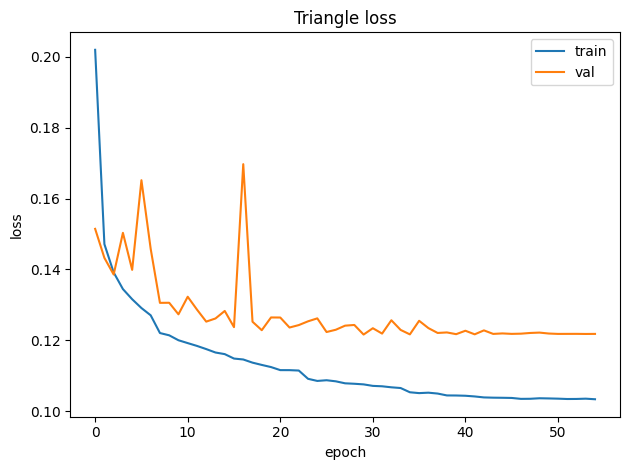

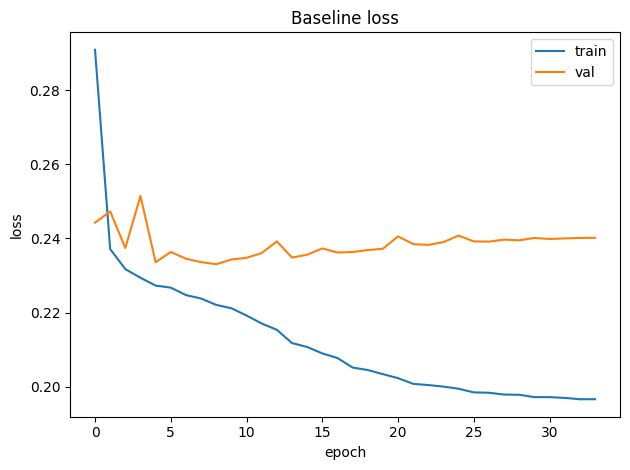

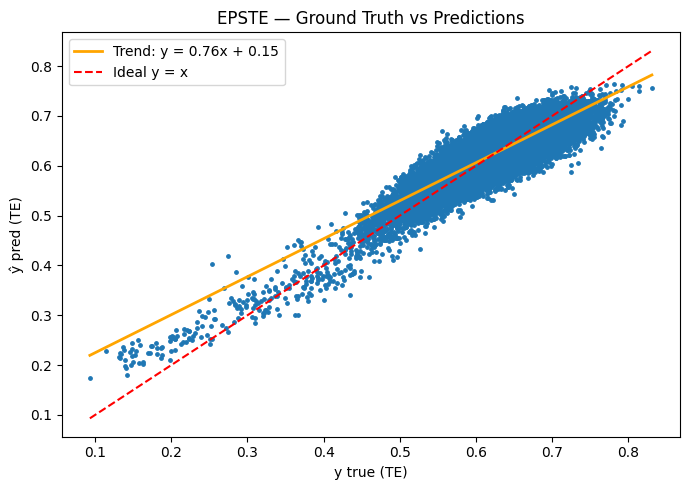

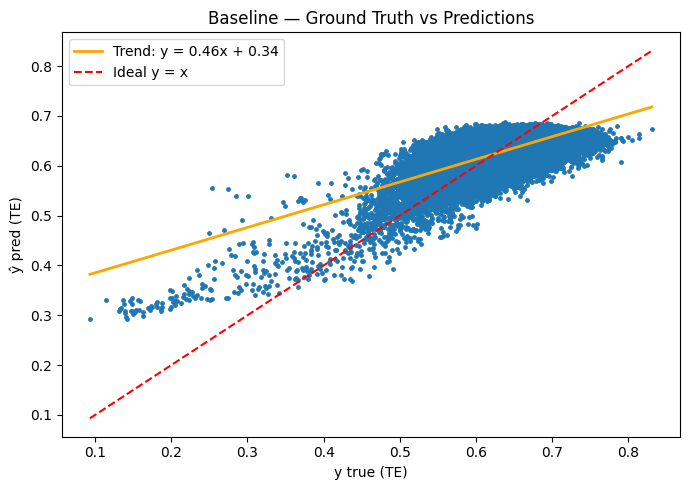

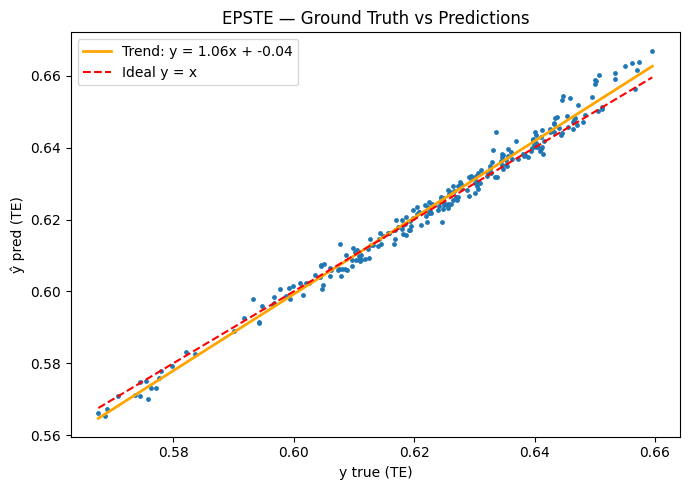

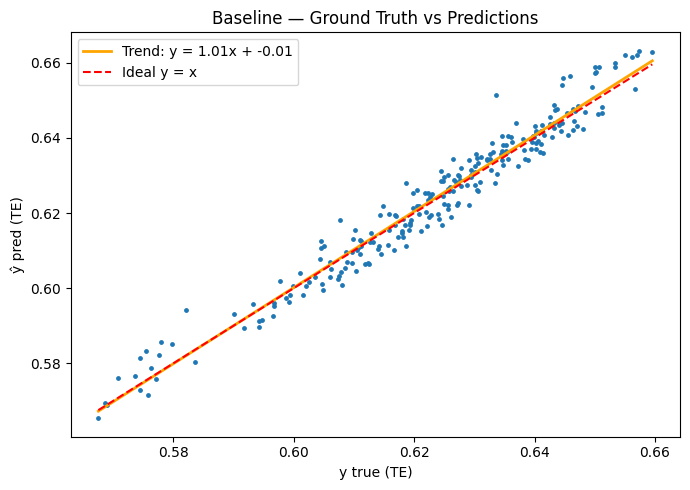

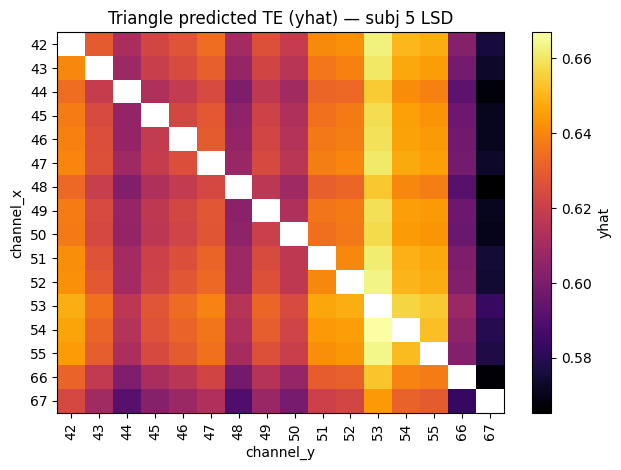

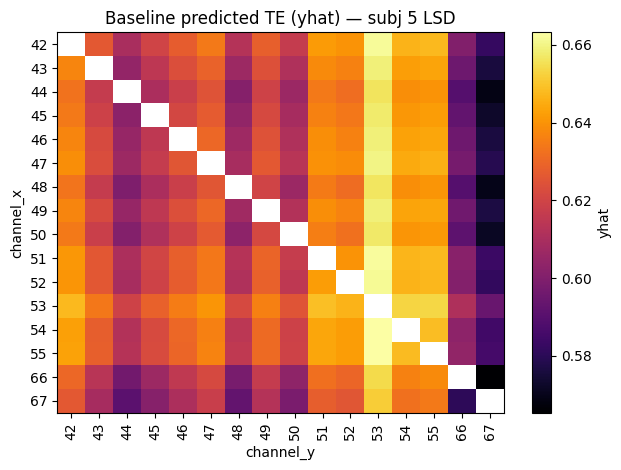

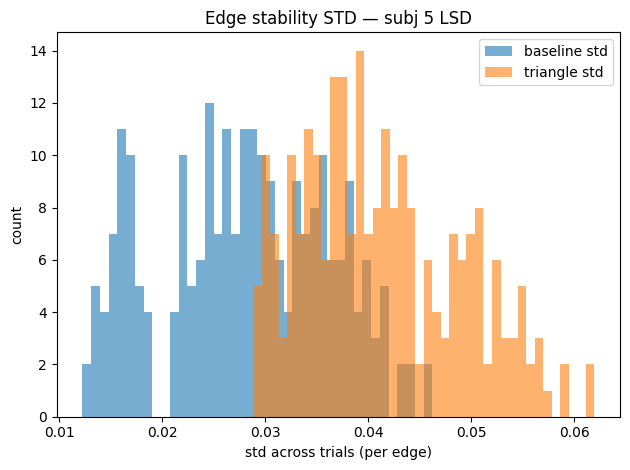

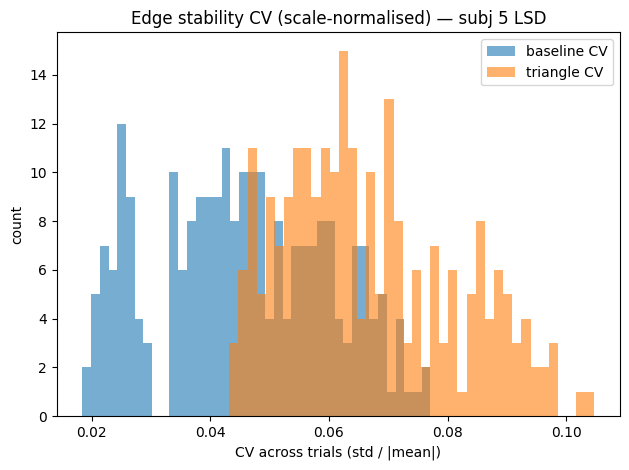

Median std (baseline): 0.02826814404074971
Median std (triangle): 0.039988173944873445
Median CV  (baseline): 0.045322798070053946
Median CV  (triangle): 0.06361372876259622
Mean abs error baseline: 0.0034021885530238767
Mean abs error triangle : 0.002091287209201919
Mean improvement (raw - tri): 0.0013109013438219574
Median improvement (raw - tri): 0.0011555135347030565
IQR improvement (raw - tri): (-0.00031138650602571816, 0.002657315627529383)
Wilcoxon paired test p-value: 2.9091960623158396e-15

Pair-level fit metrics (triangle): {'MAE': 0.002091287209201919, 'RMSE': 0.0028663262765720302, 'R2': 0.979170306485921, 'Pearson_r': 0.9933006597868189, 'Spearman_r': 0.9935762773659264}
Pair-level fit metrics (baseline): {'MAE': 0.0034021885530238767, 'RMSE': 0.004245517377797435, 'R2': 0.9543024543294566, 'Pearson_r': 0.9787916443081895, 'Spearman_r': 0.9791836663830968}


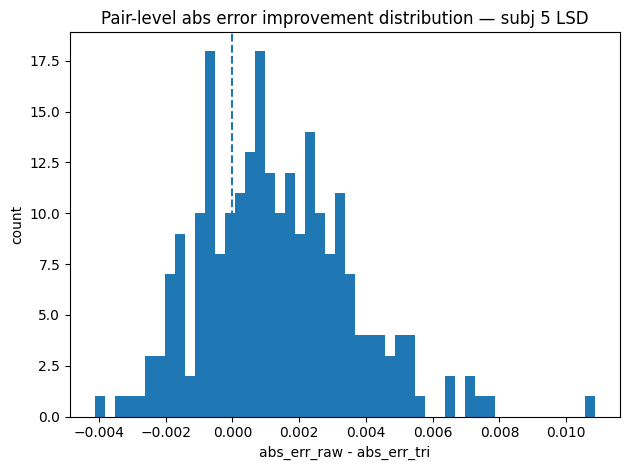


== tri pair ==
shape: (240, 7)
subject dtype: int64 example: 5
drug dtype   : object example: LSD
unique subjects (first 15): [5]
unique drugs: ['LSD']
counts by subject/drug (top 10):
subject  drug
5        LSD     240
dtype: int64

== raw pair ==
shape: (240, 7)
subject dtype: int64 example: 5
drug dtype   : object example: LSD
unique subjects (first 15): [5]
unique drugs: ['LSD']
counts by subject/drug (top 10):
subject  drug
5        LSD     240
dtype: int64
Exported results to C:\Users\david\OneDrive\Documents\Dissertation Project\TE_results.xlsx


In [ ]:
# Run full empirical evaluation pipeline (plots, metrics, error tables)
output_directory = input("What is the input data's intended ouput directory: " )

df_metrics, stab_df, per_edge_df = empirical_report(results_tri, results_raw,
                                                    tr_loss_tri=tr_loss_tri, va_loss_tri=va_loss_tri,
                                                    tr_loss_raw=tr_loss_raw, va_loss_raw=va_loss_raw,
                                                    subject=5, drug="LSD",
                                                    out_dir= output_directory)

def debug_meta(df, name):
    print(f"\n== {name} ==")
    print("shape:", df.shape)
    print("subject dtype:", df["subject"].dtype, "example:", df["subject"].iloc[0])
    print("drug dtype   :", df["drug"].dtype, "example:", df["drug"].iloc[0])
    print("unique subjects (first 15):", pd.Series(df["subject"].unique()).head(15).to_list())
    print("unique drugs:", pd.Series(df["drug"].unique()).to_list())
    print("counts by subject/drug (top 10):")
    print(df.groupby(["subject","drug"]).size().sort_values(ascending=False).head(10))

debug_meta(results_tri["pair"], "tri pair")
debug_meta(results_raw["pair"], "raw pair")

def extract_r_values(results_tri, results_raw):
    # Extract Pearson r values (TÊ vs TE) safely, avoiding degenerate divisions

    def safe_r(a, b):
        a = np.asarray(a, dtype=float)
        b = np.asarray(b, dtype=float)
        if a.size < 2 or np.std(a) == 0 or np.std(b) == 0:
            return float("nan")
        return float(np.corrcoef(a, b)[0, 1])

    def get_xy_window(df):
        # window-level uses these
        if "te_window_true" in df.columns and "te_window_pred" in df.columns:
            return df["te_window_true"].to_numpy(), df["te_window_pred"].to_numpy()
        
        if "y" in df.columns and "yhat" in df.columns:
            return df["y"].to_numpy(), df["yhat"].to_numpy()
        if "te_true" in df.columns and "te_pred" in df.columns:
            return df["te_true"].to_numpy(), df["te_pred"].to_numpy()
        raise KeyError(f"Window df missing expected cols. Columns: {list(df.columns)}")

    def get_xy_bag_pair(df):
        # bag/pair normally use these
        if "y" in df.columns and "yhat" in df.columns:
            return df["y"].to_numpy(), df["yhat"].to_numpy()
    
        if "te_true" in df.columns and "te_pred" in df.columns:
            return df["te_true"].to_numpy(), df["te_pred"].to_numpy()
        # last-resort: accept window-style names
        if "te_window_true" in df.columns and "te_window_pred" in df.columns:
            return df["te_window_true"].to_numpy(), df["te_window_pred"].to_numpy()
        raise KeyError(f"Bag/Pair df missing expected cols. Columns: {list(df.columns)}")

    rows = []
    for cond_name, res in [("triangles", results_tri), ("baseline", results_raw)]:
        # window 
        dfw = res.get("windows", res.get("window", None))
        if dfw is None or len(dfw) == 0:
            rows.append({"condition": cond_name, "level": "window", "r": float("nan"), "n": 0})
        else:
            y, yhat = get_xy_window(dfw)
            rows.append({"condition": cond_name, "level": "window", "r": safe_r(y, yhat), "n": int(len(y))})

        # bag
        dfb = res["bag"]
        y, yhat = get_xy_bag_pair(dfb)
        rows.append({"condition": cond_name, "level": "bag", "r": safe_r(y, yhat), "n": int(len(y))})

        # pair
        dfp = res["pair"]
        y, yhat = get_xy_bag_pair(dfp)
        rows.append({"condition": cond_name, "level": "pair", "r": safe_r(y, yhat), "n": int(len(y))})

    return pd.DataFrame(rows)

with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    # Core summaries
    df_metrics.to_excel(writer, sheet_name="metrics_summary", index=False)
    # Detailed results
    results_tri["pair"].to_excel(writer, sheet_name="triangle_pair_level", index=False)
    results_raw["pair"].to_excel(writer, sheet_name="baseline_pair_level", index=False)

    results_tri["bag"].to_excel(writer, sheet_name="triangle_bag_level", index=False)
    results_raw["bag"].to_excel(writer, sheet_name="baseline_bag_level", index=False)

    # Correlation-only table
    df_r = extract_r_values(results_tri, results_raw)
    df_r.to_excel(writer, sheet_name="r_values", index=False)

print(f"Exported results to {out_path}")





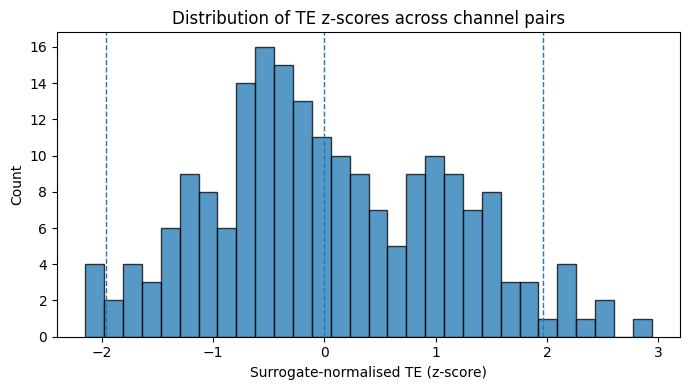

In [ ]:
z = df_pairs["z_xy"]. # values Extract z-scored transfer entropy values from surrogate test results and plot histogram
plt.figure(figsize=(7, 4))
plt.hist(z, bins=30, edgecolor="black", alpha=0.75)
# Significance thresholds
plt.axvline(0, linestyle="--", linewidth=1)
plt.axvline(1.96, linestyle="--", linewidth=1)
plt.axvline(-1.96, linestyle="--", linewidth=1)
plt.xlabel("Surrogate-normalised TE (z-score)")
plt.ylabel("Count")
plt.title("Distribution of TE z-scores across channel pairs")
plt.tight_layout()
plt.show()